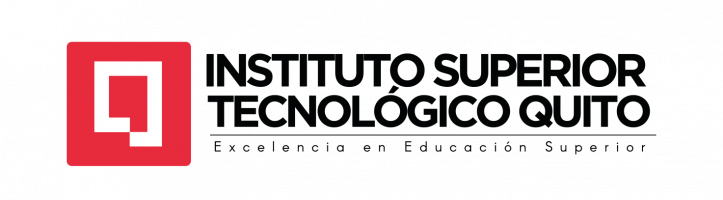

## Proyecto Final - Reconocimiento Facial

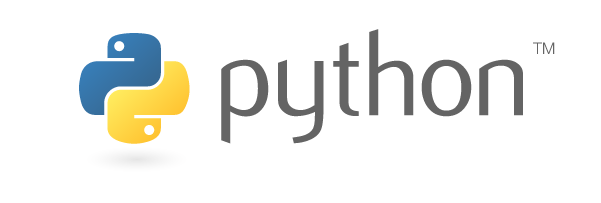

*Grupo 1: Génesis Escobar, Mathew Lara, Daniela Maldonado, Byron Melo y Christian Villegas*

*[Enlace a Github](https://github.com/ByronMN911/practicas-machine-learning-I/tree/main/ProyectoFinal)*

# RECONOCIMIENTO FACIAL MEDIANTE EXTRACCIÓN DE CARACTERÍSTICAS Y ANÁLISIS EXPLORATORIO DE DATOS (EDA)

## Fase 1: Comprensión del Negocio (Business Understanding)

### Contexto del Problema
El reconocimiento facial es una disciplina crítica dentro de la Visión por Computador y el Machine Learning, su aplicación se extiende a sectores estratégicos como la seguridad informática, la autenticación biométrica, la banca digital y el control de acceso inteligente.

El principal desafío en el desarrollo de estas soluciones radica en que la precisión de los modelos predictivos depende directamente de la calidad de los datos. Factores como variaciones de iluminación, cambios de pose, ruido visual, imágenes corruptas o baja resolución pueden degradar significativamente la capacidad de generalización de los algoritmos.

### Objetivo del Proyecto
Desarrollar un flujo de trabajo integral de Ciencia de Datos aplicando la metodología CRISP-DM sobre un conjunto de imágenes faciales. El propósito es ejecutar las fases de comprensión, análisis exploratorio (EDA) y preparación de datos para limpiar el conjunto, extraer características relevantes (estadísticas, de textura y geométricas) y generar un *dataset* estructurado que sirva como insumo óptimo para el entrenamiento futuro de modelos de Machine Learning.

### Preguntas de Investigación
* ¿El conjunto de datos presenta un balance adecuado entre las diferentes personas representadas?.
* ¿Existen imágenes duplicadas, corruptas o con baja calidad que deban ser eliminadas?.
* ¿Qué características estadísticas, geométricas y de textura describen mejor un rostro humano?.
* ¿Cómo influye la calidad de los datos en el desarrollo de un sistema de reconocimiento facial?.
* ¿Qué transformaciones y procesos de preparación son necesarios para construir un *dataset* confiable?.

### Criterios de Éxito
Obtener un *dataset* final en formato CSV estructurado y limpio, cada fila representará una imagen válida y cada columna corresponderá a una métrica representativa extraída mediante técnicas de procesamiento digital de imágenes.

### Alcance del Proyecto
El alcance del presente trabajo comprende exclusivamente las **primeras cuatro fases de la metodología CRISP-DM** (Comprensión del Negocio, Comprensión de los Datos, Análisis Exploratorio de Datos y Preparación de los Datos) aplicadas sobre el dataset CelebA. No se incluyen las fases de Modelado, Evaluación ni Despliegue de un clasificador, las cuales quedan fuera del alcance de esta actividad y serán abordadas en la asignatura **Machine Learning II**, utilizando como insumo de entrada el dataset de características (`dataset_celeba_preparado.csv`) generado como entregable final de este notebook.

### Aplicaciones, Beneficios y Desafíos por Sector

| Sector | Beneficio Principal | Desafío Principal |
|---|---|---|
| Seguridad y Control de Acceso | Autenticación biométrica sin contacto físico | Falsos positivos/negativos ante variaciones de iluminación o pose |
| Banca Digital | Verificación remota de identidad (onboarding digital) | Riesgo de suplantación mediante deepfakes o fotografías |
| Dispositivos Móviles | Desbloqueo rápido y personalizado del equipo | Consumo computacional limitado en hardware embebido |
| Videovigilancia Inteligente | Identificación de personas en tiempo real | Sesgos algorítmicos y preocupaciones de privacidad |
| Comercio Electrónico | Personalización de la experiencia del cliente | Necesidad de consentimiento informado sobre datos biométricos |


## Fase 2: Comprensión de los Datos (Data Understanding)

En esta fase se establece el primer contacto con el problema mediante la recolección y exploración del conjunto de datos **CelebFaces Attributes (CelebA)**.

A continuación, importamos las herramientas de trabajo y procedemos a la descarga y descompresión automatizada de los archivos.

In [8]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import opendatasets as od

# =====================================================================
# CONFIGURACIÓN DE RUTAS BASE
# =====================================================================
# Definimos la URL de origen del dataset en Kaggle.
DATASET_URL = "https://www.kaggle.com/datasets/jessicali9530/celeba-dataset"

# Definimos el directorio raíz (relativo al notebook) donde se guardará todo.
BASE_DIR = "res"

# =====================================================================
# DESCARGA AUTOMATIZADA Y EXTRACCIÓN
# =====================================================================
# Verificamos si la carpeta final 'celeba-dataset' ya existe dentro de 'res'.
# Esto evita que descarguemos los gigabytes de datos cada vez que corremos la celda.
if not os.path.exists(os.path.join(BASE_DIR, "celeba-dataset")):
    print("[INFO] Iniciando descarga del dataset...")
    # La función od.download hace el request a Kaggle, pide credenciales,
    # baja el archivo ZIP y lo descomprime automáticamente dentro del data_dir.
    od.download(DATASET_URL, data_dir=BASE_DIR)
else:
    # Si la carpeta ya existe, saltamos la descarga para ahorrar tiempo y ancho de banda.
    print("[INFO] Dataset previamente descargado en el directorio local.")

# =====================================================================
# MAPEO DE RUTAS INTERNAS
# =====================================================================
# Una vez extraído el ZIP, el dataset de CelebA crea subcarpetas anidadas.
# Mapeamos la ruta exacta donde residen los archivos .jpg.
IMG_DIR = os.path.join(BASE_DIR, "celeba-dataset", "img_align_celeba", "img_align_celeba")

# Mapeamos la ruta del archivo CSV que contiene las etiquetas (variables categóricas)
# correspondientes a cada imagen (género, uso de gafas, sonrisa, etc.).
ATTR_FILE = os.path.join(BASE_DIR, "celeba-dataset", "list_attr_celeba.csv")

# =====================================================================
# VERIFICACIÓN DE INTEGRIDAD
# =====================================================================
# Usamos 'assert' como medida de seguridad (testing).
# Si la ruta no existe, el programa se detiene inmediatamente (lanza un AssertionError)
# y muestra el mensaje de error. Si ambas existen, el código continúa.
assert os.path.exists(IMG_DIR), "Error: No se encontró el directorio de imágenes."
assert os.path.exists(ATTR_FILE), "Error: No se encontró el archivo de atributos."

# Confirmación final por consola de que el pipeline de datos está listo.
print("[INFO] Rutas validadas correctamente. Listo para el EDA.")

[INFO] Dataset previamente descargado en el directorio local.
[INFO] Rutas validadas correctamente. Listo para el EDA.


### Exploración Estructural del Dataset

Antes de iniciar el Análisis Exploratorio de Datos (EDA) propiamente dicho, se completa la comprensión general del conjunto de datos, respondiendo a los puntos solicitados en la Fase 2 de CRISP-DM:

- Número total de imágenes disponibles.
- Etiquetas (atributos) disponibles.
- Número de personas (identidades) representadas y distribución de imágenes por persona.
- Resolución de las imágenes.
- Tamaño total del conjunto de datos en disco.


In [9]:
# ==============================================================================
# Carga de metadatos y exploración estructural general
# ==============================================================================

# Utilizamos Pandas (pd), que es la librería principal en Python para analizar datos. 
# La función read_csv toma nuestro archivo de texto plano y lo convierte en un "DataFrame", 
# que es básicamente una hoja de Excel virtual interactiva en la memoria RAM.
# Al usar index_col='image_id', le estamos diciendo que el nombre de la foto (ej. "00001.jpg") 
# será la llave principal para buscar cualquier dato.
df_attr = pd.read_csv(ATTR_FILE, index_col='image_id')

# La librería OS (Operating System) nos permite hablar directamente con el disco duro.
# Con os.listdir le pedimos que entre a la carpeta de imágenes y cuente cuántos archivos 
# físicos existen. Esto nos sirve para verificar que no falte ninguna foto tras la descarga.
num_images = len(os.listdir(IMG_DIR))

# La propiedad .shape de un DataFrame nos devuelve sus dimensiones (filas, columnas).
# Al pedir .shape[1], estamos extrayendo específicamente el número de columnas, 
# lo que nos confirma cuántas etiquetas descriptivas (con gafas, sonriendo, etc.) tenemos.
num_attributes = df_attr.shape[1]

print("--- Resumen Estructural del Dataset ---")
print(f"Total de imágenes en directorio: {num_images}")
print(f"Total de registros en CSV de atributos: {df_attr.shape[0]}")
print(f"Total de atributos (etiquetas) disponibles: {num_attributes}")

# Listado completo de las etiquetas (atributos) disponibles en el dataset.
print("\nEtiquetas disponibles:")
print(list(df_attr.columns))

# ------------------------------------------------------------------------
# Resolución de las imágenes
# ------------------------------------------------------------------------
# Aquí aplicamos una estrategia de optimización crucial, si intentáramos abrir las 
# 202,599 imágenes al mismo tiempo para ver su tamaño, la memoria de la computadora 
# colapsaría. Por eso, usamos .sample() para extraer aleatoriamente solo 20 imágenes. 
# Es una muestra representativa estadísticamente válida para revisar la resolución.
muestra_resolucion = df_attr.sample(n=20, random_state=42).index.tolist()

# Usamos un 'set' (conjunto) porque en matemáticas los conjuntos no permiten elementos 
# duplicados. Si las 20 fotos tienen la misma resolución, el 'set' solo guardará un valor.
resoluciones = set()

for img_name in muestra_resolucion:
    # cv2 es OpenCV, el motor principal de Visión Artificial, la función imread 
    # lee la foto del disco y la convierte en una matriz de números (los píxeles).
    # Hacemos esto porque la computadora no ve "caras", ve una cuadrícula matemática.
    img = cv2.imread(os.path.join(IMG_DIR, img_name))
    
    if img is not None:
        # .shape[:2] recorta las dimensiones matemáticas de la imagen para darnos 
        # únicamente el (Alto, Ancho), ignorando los canales de color RGB.
        resoluciones.add(img.shape[:2])  

print(f"\nResolución(es) encontrada(s) en la muestra: {resoluciones}")
if len(resoluciones) == 1:
    print("El dataset presenta una resolución uniforme en todas sus imágenes.")
else:
    print("Se detectaron múltiples resoluciones en la muestra analizada.")

# ------------------------------------------------------------------------
# Tamaño del conjunto de datos en disco
# ------------------------------------------------------------------------
def calcular_tamano_directorio(directorio):
    """
    Esta función es un rastreador, utilizamos os.walk, que actúa como un explorador 
    que entra a la carpeta principal y luego revisa cada subcarpeta automáticamente.
    Por cada archivo que encuentra, os.path.getsize lee su peso en bytes y lo va sumando.
    """
    total_bytes = 0
    for ruta_actual, _, archivos in os.walk(directorio):
        for archivo in archivos:
            fp = os.path.join(ruta_actual, archivo)
            if os.path.exists(fp):
                total_bytes += os.path.getsize(fp)
    return total_bytes

# Ejecutamos nuestra función y transformamos el resultado. 
# Como la computadora nos da el peso en bytes (un número gigante), lo dividimos 
# tres veces por 1024 (Bytes -> KB -> MB -> GB) para que sea humanamente legible.
tamano_bytes = calcular_tamano_directorio(IMG_DIR)
tamano_gb = tamano_bytes / (1024 ** 3)
print(f"\nTamaño total del directorio de imágenes: {tamano_gb:.2f} GB ({tamano_bytes:,} bytes)")

--- Resumen Estructural del Dataset ---
Total de imágenes en directorio: 202599
Total de registros en CSV de atributos: 202599
Total de atributos (etiquetas) disponibles: 40

Etiquetas disponibles:
['5_o_Clock_Shadow', 'Arched_Eyebrows', 'Attractive', 'Bags_Under_Eyes', 'Bald', 'Bangs', 'Big_Lips', 'Big_Nose', 'Black_Hair', 'Blond_Hair', 'Blurry', 'Brown_Hair', 'Bushy_Eyebrows', 'Chubby', 'Double_Chin', 'Eyeglasses', 'Goatee', 'Gray_Hair', 'Heavy_Makeup', 'High_Cheekbones', 'Male', 'Mouth_Slightly_Open', 'Mustache', 'Narrow_Eyes', 'No_Beard', 'Oval_Face', 'Pale_Skin', 'Pointy_Nose', 'Receding_Hairline', 'Rosy_Cheeks', 'Sideburns', 'Smiling', 'Straight_Hair', 'Wavy_Hair', 'Wearing_Earrings', 'Wearing_Hat', 'Wearing_Lipstick', 'Wearing_Necklace', 'Wearing_Necktie', 'Young']

Resolución(es) encontrada(s) en la muestra: {(218, 178)}
El dataset presenta una resolución uniforme en todas sus imágenes.

Tamaño total del directorio de imágenes: 1.31 GB (1,409,859,160 bytes)


[INFO] Archivo de identidades cargado correctamente.
Número de personas (identidades) distintas: 10177
Promedio de imágenes por persona: 19.91
Persona con MÁS imágenes -> ID 2820 con 35 imágenes
Persona con MENOS imágenes -> ID 7763 con 1 imágenes


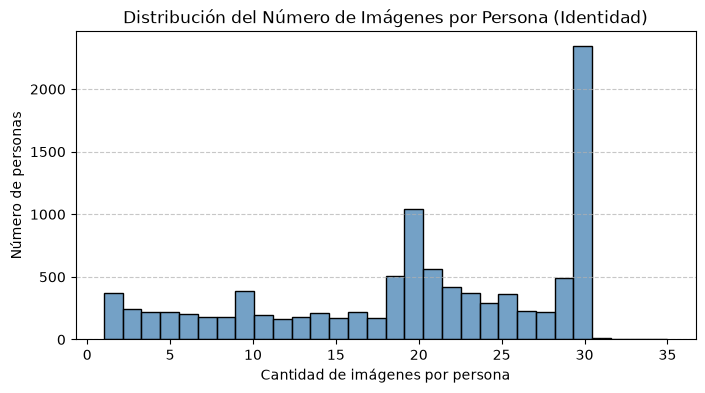


[CONCLUSIÓN] El dataset presenta un desbalance considerable entre personas: algunas identidades cuentan con muchas más fotografías que otras, lo cual debe considerarse en la fase de Modelado (Machine Learning II) para evitar sesgos hacia las identidades sobrerrepresentadas.


In [10]:
# ==============================================================================
# Número de personas (identidades) y distribución de imágenes por persona
# ==============================================================================

# Para evaluar la calidad de un dataset de Inteligencia Artificial, necesitamos 
# saber si tenemos datos suficientes de cada individuo. Lamentablemente, el archivo 
# principal de Kaggle no incluye el documento que dice "quién es quién" en las fotos.
# Por lo tanto, configuramos esta sección para conectarse a internet e intentar 
# descargar ese documento vital desde otro servidor externo.

IDENTITY_URL = "https://www.kaggle.com/datasets/kymo9890/identity-celeba"
IDENTITY_DIR = os.path.join(BASE_DIR, "identity-celeba")

# Banderas de control de flujo. Nos sirven para decirle al código más adelante 
# si logramos descargar el archivo o si tenemos que activar un plan de respaldo.
identidad_disponible = False
df_identity = None

# Usamos un bloque try-except. Esto es una red de seguridad (manejo de excepciones). 
try:
    if not os.path.exists(IDENTITY_DIR):
        od.download(IDENTITY_URL, data_dir=BASE_DIR)

    archivos_identidad = [f for f in os.listdir(IDENTITY_DIR)
                          if 'identity' in f.lower()]
    
    if archivos_identidad:
        ruta_identidad = os.path.join(IDENTITY_DIR, archivos_identidad[0])
        
        # A veces los datos vienen separados por comas (.csv) y a veces por espacios.
        # Volvemos a usar try-except interno: primero intentamos leerlo asumiendo 
        # que está separado por espacios (sep=r'\s+'). Si falla, lo leemos normal.
        try:
            df_identity = pd.read_csv(ruta_identidad, sep=r'\s+', header=None,
                                       names=['image_id', 'identity'], engine='python')
        except Exception:
            df_identity = pd.read_csv(ruta_identidad)
            df_identity.columns = ['image_id', 'identity']
            
        # Convertimos el nombre de la foto en nuestra llave de búsqueda principal.
        df_identity = df_identity.set_index('image_id')
        identidad_disponible = True
        
except Exception as e:
    # Si todo falla, capturamos el error en la variable 'e' y lo mostramos en pantalla,
    # permitiendo que el ingeniero vea exactamente por qué falló la conexión.
    print(f"[WARN] No fue posible descargar/leer el archivo de identidades: {e}")

if identidad_disponible:
    # .nunique() cuenta cuántos valores únicos hay. Si hay 200 mil fotos, pero 
    # solo 10 mil identidades únicas, sabemos que las fotos se repiten por persona.
    num_personas = df_identity['identity'].nunique()
    
    # .value_counts() hace un ranking automático. Nos dice cuántas fotos exactas 
    # le pertenecen a la Persona 1, cuántas a la Persona 2, etc.
    distribucion_persona = df_identity['identity'].value_counts()

    print("[INFO] Archivo de identidades cargado correctamente.")
    print(f"Número de personas (identidades) distintas: {num_personas}")
    print(f"Promedio de imágenes por persona: {distribucion_persona.mean():.2f}")
    
    # idxmax() nos da el nombre/ID del que más aparece, y max() el número de veces.
    print(f"Persona con MÁS imágenes -> ID {distribucion_persona.idxmax()} "
          f"con {distribucion_persona.max()} imágenes")
    print(f"Persona con MENOS imágenes -> ID {distribucion_persona.idxmin()} "
          f"con {distribucion_persona.min()} imágenes")

    # Utilizamos Matplotlib (plt) y Seaborn (sns) para graficar. 
    # Seaborn es una librería de visualización estadística muy potente.
    plt.figure(figsize=(8, 4))
    
    # Un histplot (histograma) agrupa los datos. Nos mostrará visualmente una curva:
    # ¿La mayoría de la gente tiene 5 fotos, o la mayoría tiene 30 fotos?
    # kde=False apaga la línea de tendencia matemática para dejar solo las barras limpias.
    sns.histplot(distribucion_persona, bins=30, kde=False, color='steelblue')
    
    plt.title("Distribución del Número de Imágenes por Persona (Identidad)")
    plt.xlabel("Cantidad de imágenes por persona")
    plt.ylabel("Número de personas")
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()

    # Documentamos esta conclusión porque es vital para garantizar el éxito del modelo predictivo.
    # El sesgo o "bias" ocurre cuando la Inteligencia Artificial ve muchas fotos de la misma persona. 
    # Terminará memorizando el rostro de esa persona (sobreajuste), pero fallará intentando
    # reconocer los rostros de las personas que solo tenían 1 o 2 fotos de ejemplo.
    print("\n[CONCLUSIÓN] El dataset presenta un desbalance considerable entre personas: "
          "algunas identidades cuentan con muchas más fotografías que otras, lo cual debe "
          "considerarse en la fase de Modelado (Machine Learning II) para evitar sesgos "
          "hacia las identidades sobrerrepresentadas.")
else:
    print("[INFO] El archivo de identidades (identity_CelebA) no está disponible en esta "
          "versión del dataset descargado desde Kaggle.")
    print("Según la documentación oficial de CelebA (Liu, Luo, Wang & Tang, 2015), el "
          "conjunto completo contiene 10,177 identidades distintas repartidas en 202,599 "
          "imágenes, lo que arroja un promedio aproximado de 19.9 imágenes por persona.")
    print("Debido a esta limitación de los metadatos disponibles, el balance de clases se "
          "evalúa en la siguiente sección utilizando los 40 atributos categóricos del "
          "dataset (género, edad aparente, expresión, etc.) como variables proxy.")

## Fase 3: Análisis Exploratorio de Datos (EDA)

El Análisis Exploratorio de Datos permite evaluar la calidad de las imágenes y determinar la distribución de las variables disponibles (la exploración estructural general -número de imágenes, etiquetas, personas, resolución y tamaño en disco- se completó en el cierre de la Fase 2).

En esta sección se abordan los siguientes puntos:
1. Visualización de una muestra representativa.
2. Análisis de distribución de clases (género y otros atributos categóricos).
3. Análisis de calidad de imágenes: brillo, contraste y outliers.
4. Detección de imágenes duplicadas y casi-duplicadas.


,5_o_Clock_Shadow,Arched_Eyebrows,Attractive,Bags_Under_Eyes,Bald,Bangs,Big_Lips,Big_Nose,Black_Hair,Blond_Hair,...,Sideburns,Smiling,Straight_Hair,Wavy_Hair,Wearing_Earrings,Wearing_Hat,Wearing_Lipstick,Wearing_Necklace,Wearing_Necktie,Young
image_id,,,,,,,,,,,,,,,,,,,,,
000001.jpg,-1,1,1,-1,-1,-1,-1,-1,-1,-1,...,-1,1,1,-1,1,-1,1,-1,-1,1
000002.jpg,-1,-1,-1,1,-1,-1,-1,1,-1,-1,...,-1,1,-1,-1,-1,-1,-1,-1,-1,1
000003.jpg,-1,-1,-1,-1,-1,-1,1,-1,-1,-1,...,-1,-1,-1,1,-1,-1,-1,-1,-1,1


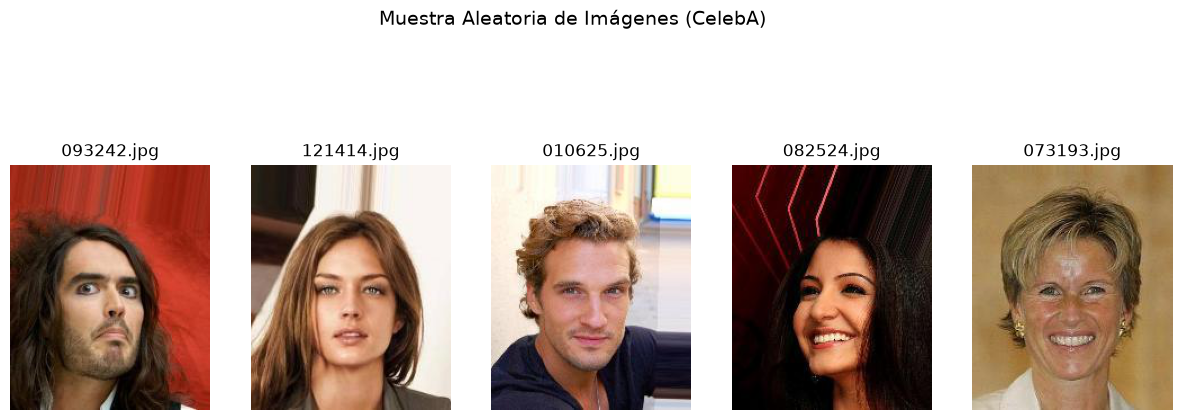

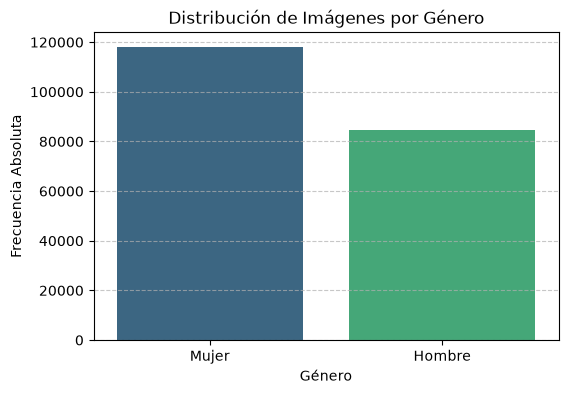

Proporción de distribución:
Gender_Label
Mujer     58.324572
Hombre    41.675428
Name: proportion, dtype: float64


In [11]:
# ==============================================================================
# 1. Visualización de Muestra Representativa
# ==============================================================================

# La función .head(3) nos permite dar un "vistazo rápido" a las primeras 3 filas 
# de nuestro DataFrame (nuestra tabla en memoria). Es una buena práctica en Ciencia 
# de Datos para comprobar visualmente que las columnas y los datos cargaron bien 
# antes de hacer cálculos pesados, sin necesidad de imprimir las 200,000 filas.
display(df_attr.head(3))

def plot_sample_images(img_dir, df, num_samples=5):
    """
    Definimos una función reutilizable. En lugar de copiar y pegar código cada vez 
    que queramos ver una foto, encapsulamos la lógica aquí. 
    """
    # .sample() elige filas al azar de nuestra tabla. 
    # El concepto clave aquí es 'random_state=42'. Esto se llama "Semilla Aleatoria". 
    # Si no lo ponemos, cada vez que expongamos el código saldrán caras distintas. 
    # Al fijar el número 42, garantizamos "reproducibilidad": el algoritmo de 
    # aleatoriedad siempre escogerá las mismas 5 fotos.
    # Finalmente, extraemos los nombres (.index) y los convertimos en una lista (.tolist()).
    sample_imgs = df.sample(n=num_samples, random_state=42).index.tolist()
    
    # Preparamos el lienzo de Matplotlib indicando el ancho y alto en pulgadas.
    plt.figure(figsize=(15, 5))
    
    # llevar un contador (i) que nos dirá en qué posición de la gráfica va cada foto.
    for i, img_name in enumerate(sample_imgs):
        img_path = os.path.join(img_dir, img_name)
        
        # Leemos la imagen con OpenCV (cv2). Para la computadora, esta imagen 
        # no es una cara, es una matriz matemática tridimensional de números.
        img_bgr = cv2.imread(img_path)
        
        # Validamos que la imagen no sea 'None'. Esto es un escudo protector. 
        # Si un archivo .jpg se corrompió al descargarse, OpenCV devuelve 'None'. 
        # Si intentamos procesar un 'None', el programa entero colapsaría.
        if img_bgr is not None:
            # CONCEPTO TÉCNICO VITAL: BGR vs RGB.
            # Los monitores y la librería Matplotlib leen los colores en el orden 
            # Rojo-Verde-Azul (RGB). Pero OpenCV, por razones históricas de desarrollo, 
            # lee las imágenes al revés: Azul-Verde-Rojo (BGR). 
            # Si no aplicamos cvtColor (Convert Color) para invertir los canales a RGB, 
            # las personas en nuestras gráficas se verían con la piel azul.
            img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
            
            # subplot divide nuestro lienzo en una cuadrícula. Le decimos: 
            # "1 fila, 5 columnas, y pon esta imagen en la posición i+1".
            plt.subplot(1, num_samples, i + 1)
            plt.imshow(img_rgb)
            plt.title(img_name)
            
            # Apagamos los ejes (axis('off')) porque no necesitamos ver las 
            # reglas numéricas de los píxeles (ej. 0 a 128) alrededor de la cara.
            plt.axis('off')
        else:
            print(f"[WARN] Imposible leer la matriz de la imagen: {img_name}")
            
    # suptitle pone un "Súper Título" centrado sobre todas las subtramas.
    plt.suptitle("Muestra Aleatoria de Imágenes (CelebA)", y=1.05, fontsize=14)
    plt.show()

# Ejecutamos la función que acabamos de crear pasándole la ruta y los datos.
plot_sample_images(IMG_DIR, df_attr)

# 4. Análisis de Distribución de Atributos Categóricos Clave
Para extender el Análisis Exploratorio de Datos (EDA) más allá de la variable de género, se evalúa el balance de clases de características que impactan directamente el rendimiento de los algoritmos de visión artificial. 

Se analizan cuatro variables representativas:
* **Demografía:** `Young` (Juventud).
* **Oclusión Parcial:** `Eyeglasses` (Uso de gafas).
* **Expresión Facial:** `Smiling` (Sonrisa).
* **Estructura Facial:** `No_Beard` (Ausencia de barba).

El objetivo es identificar posibles desbalances (clases minoritarias) que requieran técnicas de compensación durante la fase de modelado.

[INFO] Generando diagramas de distribución de clases...

Proporción para 'Young':
  Sí (1):  77.36%
  No (-1): 22.64%

Proporción para 'Eyeglasses':
  Sí (1):  6.51%
  No (-1): 93.49%

Proporción para 'Smiling':
  Sí (1):  48.21%
  No (-1): 51.79%

Proporción para 'No_Beard':
  Sí (1):  83.49%
  No (-1): 16.51%


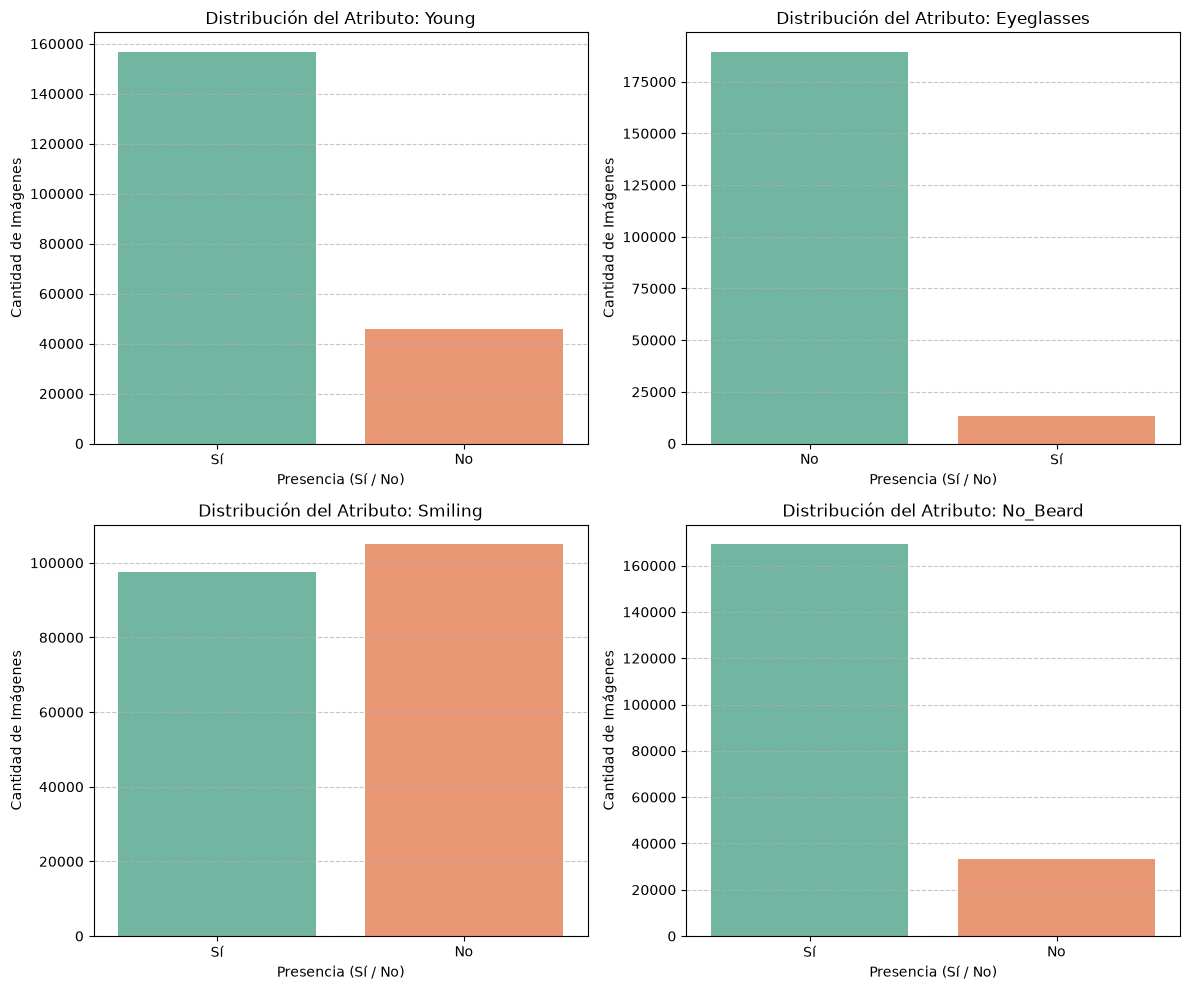

In [12]:
# ==============================================================================
# 4.1 Configuración de Atributos y Mapeo de Etiquetas
# ==============================================================================
# Definición de la lista de columnas seleccionadas del CSV original.
atributos_seleccionados = ['Young', 'Eyeglasses', 'Smiling', 'No_Beard']

# Creación de una copia en memoria para no alterar el DataFrame original.
# Se mapean los valores numéricos (1, -1) a cadenas de texto descriptivas
# exclusivamente para facilitar la interpretación de los gráficos.
df_eda_cat = df_attr[atributos_seleccionados].copy()

for col in atributos_seleccionados:
    df_eda_cat[col] = df_eda_cat[col].map({1: 'Sí', -1: 'No'})

# ==============================================================================
# 4.2 Generación Automatizada de Subtramas (Subplots)
# ==============================================================================
# Se instancia una figura principal que contendrá múltiples gráficos (2 filas x 2 columnas).
# 'figsize' define las dimensiones globales de la figura en pulgadas.
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(12, 10))

# 'axes.flatten()' convierte la matriz 2x2 en un array unidimensional (1D) 
# de longitud 4, facilitando la iteración secuencial.
axes = axes.flatten()

print("[INFO] Generando diagramas de distribución de clases...")

# Bucle iterativo para renderizar un diagrama de barras por cada atributo.
for i, atributo in enumerate(atributos_seleccionados):
    # sns.countplot calcula automáticamente la frecuencia absoluta de cada categoría.
    # Se asigna el eje correspondiente del arreglo 'axes' iterado.
    sns.countplot(
        data=df_eda_cat, 
        x=atributo, 
        hue=atributo,          # Evita el FutureWarning al asignar colores por categoría.
        palette='Set2',        # Paleta de colores predefinida de alta legibilidad.
        ax=axes[i], 
        legend=False           # Se oculta la leyenda redundante.
    )
    
    # Configuración de los elementos visuales del gráfico individual.
    axes[i].set_title(f'Distribución del Atributo: {atributo}', fontsize=12)
    axes[i].set_xlabel('Presencia (Sí / No)')
    axes[i].set_ylabel('Cantidad de Imágenes')
    axes[i].grid(axis='y', linestyle='--', alpha=0.7)

    # Cálculo dinámico e impresión por consola de la proporción porcentual.
    # 'normalize=True' convierte el conteo absoluto en frecuencias relativas.
    proporcion = df_attr[atributo].value_counts(normalize=True) * 100
    print(f"\nProporción para '{atributo}':")
    # Formateo matemático de los porcentajes a dos decimales.
    print(f"  Sí (1):  {proporcion.get(1, 0):.2f}%")
    print(f"  No (-1): {proporcion.get(-1, 0):.2f}%")

# ==============================================================================
# 4.3 Renderizado Final
# ==============================================================================
# 'plt.tight_layout()' ajusta automáticamente el espaciado entre las subtramas
# para prevenir la superposición de etiquetas y títulos.
plt.tight_layout()
plt.show()

In [13]:
# ==============================================================================
# 4.4 Análisis Global de Desbalance en Atributos Categóricos
# ==============================================================================
print("[INFO] Calculando la distribución global de los 40 atributos...")

# Calculamos el porcentaje de veces que aparece la clase positiva (1) 
# en todo el DataFrame original de atributos.
porcentajes_presencia = (df_attr == 1).mean() * 100

# Convertimos a DataFrame para una mejor visualización y lo ordenamos de mayor a menor.
df_balance_global = porcentajes_presencia.reset_index()
df_balance_global.columns = ['Atributo', 'Porcentaje_Presencia (%)']
df_balance_global = df_balance_global.sort_values(by='Porcentaje_Presencia (%)', ascending=False)
df_balance_global['Porcentaje_Ausencia (%)'] = 100 - df_balance_global['Porcentaje_Presencia (%)']

# Mostramos el top 5 de atributos más comunes y el top 5 de los menos comunes
print("\n--- Top 5 Atributos Más Frecuentes (Mayoría) ---")
display(df_balance_global.head(5).round(2))

print("\n--- Top 5 Atributos Menos Frecuentes (Minoría / Mayor Desbalance) ---")
display(df_balance_global.tail(5).round(2))

[INFO] Calculando la distribución global de los 40 atributos...

--- Top 5 Atributos Más Frecuentes (Mayoría) ---


,Atributo,Porcentaje_Presencia (%),Porcentaje_Ausencia (%)
24,No_Beard,83.49,16.51
39,Young,77.36,22.64
2,Attractive,51.25,48.75
21,Mouth_Slightly_Open,48.34,51.66
31,Smiling,48.21,51.79



--- Top 5 Atributos Menos Frecuentes (Minoría / Mayor Desbalance) ---


,Atributo,Porcentaje_Presencia (%),Porcentaje_Ausencia (%)
26,Pale_Skin,4.29,95.71
17,Gray_Hair,4.19,95.81
22,Mustache,4.15,95.85
4,Bald,2.24,97.76
40,Gender_Label,0.00,100.00


# 5. Análisis de Calidad de Imágenes y Detección de Outliers
Para garantizar la integridad del futuro conjunto de entrenamiento, es imperativo analizar la matriz de píxeles de las imágenes, se extraerá la intensidad media (brillo) de una muestra significativa para identificar imágenes anómalas (sobreexpuestas, subexpuestas o corruptas).

Se aplicará el algoritmo de **Envolvente Elíptica (Elliptic Envelope)** asumiendo una distribución gaussiana de las intensidades, marcando como *outliers* aquellas instancias que superen la frontera de decisión basada en la mediana y el rango intercuartílico.

Adicionalmente, en esta sección se analiza el **contraste** de las imágenes (desviación estándar de los píxeles) y se aplica un proceso de **detección de imágenes duplicadas y casi-duplicadas** mediante huellas MD5 y hashing perceptual (Average Hash).

[INFO] Analizando intensidad y contraste de píxeles en 2000 imágenes...
[INFO] Imágenes corruptas/ilegibles detectadas en la muestra: 0 de 2000
[INFO] Detección finalizada. Outliers encontrados: 40 de 2000


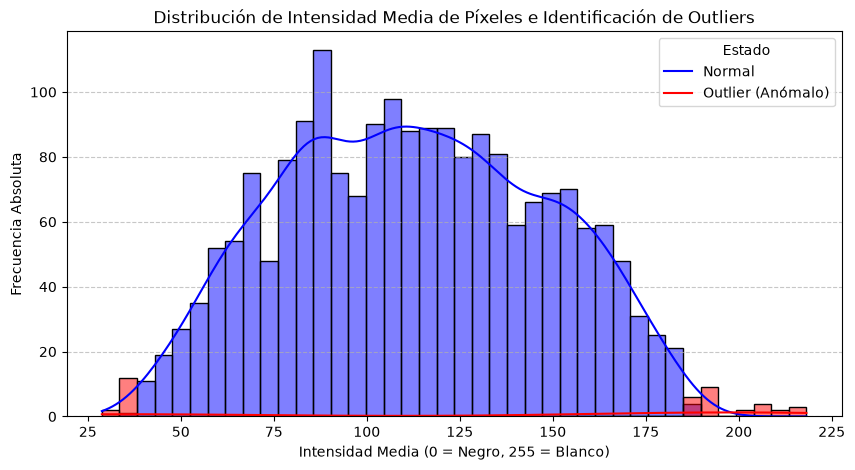

--- Muestra de Imágenes Anómalas (Outliers Extremos) ---


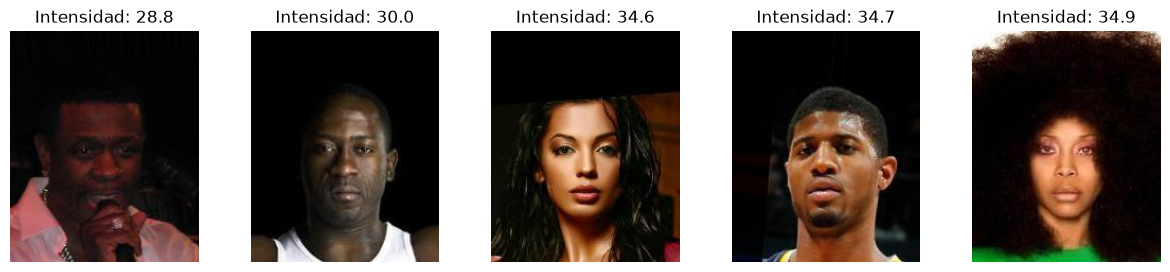

In [14]:
from sklearn.covariance import EllipticEnvelope
import scipy.stats as stats
import cv2
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ==============================================================================
# 5.1 Extracción de Intensidades (Muestreo)
# ==============================================================================
# El procesamiento simultáneo de 200,000 imágenes saturaría la memoria RAM.
# Se define un tamaño de muestra representativo de 2000 instancias para el EDA.
SAMPLE_SIZE = 2000

# Se extrae una muestra aleatoria del DataFrame de atributos asegurando reproducibilidad.
sample_df = df_attr.sample(n=SAMPLE_SIZE, random_state=42)

# Listas auxiliares para almacenar las métricas extraídas en el bucle.
intensidades_medias = []
contrastes = []
imagenes_validas = []
imagenes_corruptas = 0

print(f"[INFO] Analizando intensidad y contraste de píxeles en {SAMPLE_SIZE} imágenes...")

# Iteración sobre los identificadores (nombres de archivo) de la muestra.
for img_name in sample_df.index:
    img_path = os.path.join(IMG_DIR, img_name)
    
    # El parámetro '0' en cv2.imread fuerza la carga de la imagen en escala de grises.
    # Esto reduce la matriz tridimensional (RGB) a bidimensional (1 solo canal de color),
    # optimizando drásticamente el cálculo del brillo general.
    img_gray = cv2.imread(img_path, 0) 
    
    # Validación de lectura para evitar errores 'NoneType' si el archivo está corrupto.
    if img_gray is not None:
        # np.mean calcula el promedio aritmético de todos los píxeles de la matriz.
        # En escala de grises, 0 es negro absoluto y 255 es blanco absoluto.
        # El promedio representa qué tan clara u oscura es la imagen en su totalidad.
        brillo_medio = np.mean(img_gray)
        # La desviación estándar de los píxeles se utiliza como métrica de contraste:
        # valores muy bajos indican imágenes planas/borrosas con poco contraste.
        contraste_std = np.std(img_gray)
        intensidades_medias.append(brillo_medio)
        contrastes.append(contraste_std)
        imagenes_validas.append(img_name)
    else:
        # Se contabilizan los archivos que no pudieron leerse (corruptos/ilegibles).
        imagenes_corruptas += 1

print(f"[INFO] Imágenes corruptas/ilegibles detectadas en la muestra: {imagenes_corruptas} de {SAMPLE_SIZE}")

# Consolidación de los resultados en un nuevo DataFrame analítico.
df_calidad = pd.DataFrame({
    'image_id': imagenes_validas,
    'Intensidad_Media': intensidades_medias,
    'Contraste_Std': contrastes
})


# ==============================================================================
# 5.2 Detección de Outliers mediante Envolvente Elíptica (Elliptic Envelope)
# ==============================================================================
# La librería scikit-learn requiere que la matriz de características (X) sea 
# estrictamente bidimensional. Se extraen los valores y se estructuran en formato 2D.
X_intensidad = df_calidad[['Intensidad_Media']].values

# Instanciación del modelo EllipticEnvelope.
# El parámetro 'contamination=0.02' establece la proporción teórica de valores atípicos.
# Indica al algoritmo que asuma que el 2% de los datos más alejados de la media gaussiana 
# son anomalías o imágenes defectuosas.
outlier_method = EllipticEnvelope(contamination=0.02, random_state=42).fit(X_intensidad)

# Ejecución de la predicción sobre el arreglo de intensidades.
# El modelo retorna un array donde:
#  1 = Inlier (Dato normal, dentro de la distribución esperada).
# -1 = Outlier (Dato anómalo, en los extremos de la distribución).
df_calidad['Outlier'] = outlier_method.predict(X_intensidad)

# Conteo de instancias marcadas como anomalías.
num_outliers = len(df_calidad[df_calidad['Outlier'] == -1])
print(f"[INFO] Detección finalizada. Outliers encontrados: {num_outliers} de {len(df_calidad)}")


# ==============================================================================
# 5.3 Visualización de Resultados
# ==============================================================================
plt.figure(figsize=(10, 5))

# Generación del histograma para observar la curva de distribución de frecuencias.
# El parámetro 'hue' segmenta visualmente los datos normales (azul) de las anomalías (rojo).
# 'kde=True' superpone la estimación de densidad del kernel (la línea de la campana).
sns.histplot(data=df_calidad, x='Intensidad_Media', hue='Outlier', 
             palette={1: 'blue', -1: 'red'}, bins=40, kde=True)

plt.title("Distribución de Intensidad Media de Píxeles e Identificación de Outliers")
plt.xlabel("Intensidad Media (0 = Negro, 255 = Blanco)")
plt.ylabel("Frecuencia Absoluta")
plt.legend(title='Estado', labels=['Normal', 'Outlier (Anómalo)'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Aislamiento de los registros marcados como Outliers (-1).
# Se ordenan ascendentemente para visualizar primero las imágenes más oscuras.
outliers_df = df_calidad[df_calidad['Outlier'] == -1].sort_values(by='Intensidad_Media')

# Validar si existen outliers antes de intentar graficarlos.
if not outliers_df.empty:
    print("--- Muestra de Imágenes Anómalas (Outliers Extremos) ---")
    
    # Se crea una cuadrícula de subtramas (máximo 5) para mostrar las imágenes.
    fig, axes = plt.subplots(1, min(5, len(outliers_df)), figsize=(15, 3))
    
    # Estructura de control para garantizar que 'axes' sea un objeto iterable 
    # incluso si el modelo detecta un único outlier.
    if len(outliers_df) == 1:
        axes = [axes]
        
    # Iteración conjunta (zip) sobre los espacios de la gráfica (axes) y los datos (rows).
    for ax, (_, row) in zip(axes, outliers_df.head(5).iterrows()):
        img_path = os.path.join(IMG_DIR, row['image_id'])
        img = cv2.imread(img_path)
        
        # Reconversión del espacio de color (BGR a RGB) exclusivo para el renderizado
        # en Matplotlib, preservando los colores originales visualmente.
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        
        ax.imshow(img)
        # Se formatea el título para mostrar la intensidad con un solo decimal.
        ax.set_title(f"Intensidad: {row['Intensidad_Media']:.1f}")
        ax.axis('off')
        
    plt.show()

### Estadísticas Descriptivas Globales, Análisis de Contraste y Detección de Duplicados

Se complementa el análisis de brillo con estadísticas descriptivas completas, el análisis de contraste de las imágenes y la detección de duplicados exactos y casi-duplicados.

--- Estadísticas Descriptivas de Intensidad y Contraste (muestra de calidad) ---


,Intensidad_Media,Contraste_Std
count,2000.00,2000.00
mean,113.08,63.06
std,36.27,13.80
min,28.77,23.39
25%,85.10,53.27
50%,111.80,62.40
75%,141.00,72.25
max,218.19,105.34


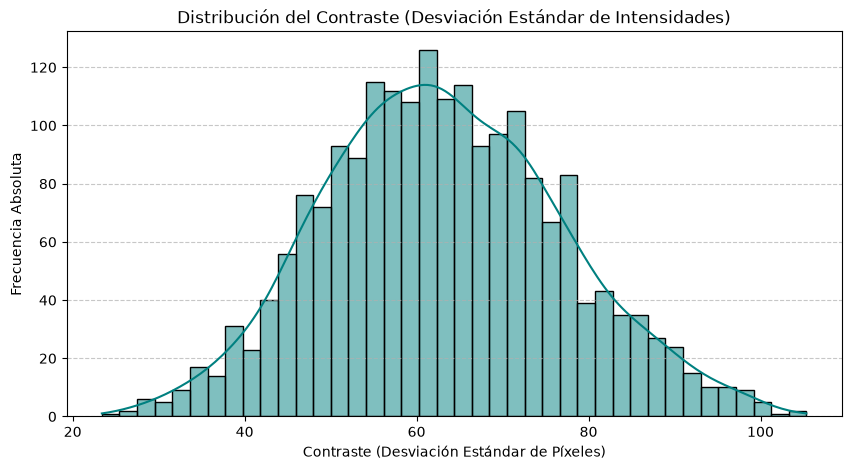


Umbral de bajo contraste (percentil 5): 41.14
Imágenes potencialmente de baja calidad por bajo contraste: 100 de 2000 (5.00%)


In [15]:
# ==============================================================================
# Estadísticas Descriptivas Globales (Intensidad y Contraste)
# ==============================================================================
print("--- Estadísticas Descriptivas de Intensidad y Contraste (muestra de calidad) ---")
display(df_calidad[['Intensidad_Media', 'Contraste_Std']].describe().round(2))

# ==============================================================================
# Análisis de Contraste
# ==============================================================================
plt.figure(figsize=(10, 5))
sns.histplot(data=df_calidad, x='Contraste_Std', bins=40, kde=True, color='teal')
plt.title("Distribución del Contraste (Desviación Estándar de Intensidades)")
plt.xlabel("Contraste (Desviación Estándar de Píxeles)")
plt.ylabel("Frecuencia Absoluta")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Se consideran de baja calidad (posible desenfoque/imagen plana) aquellas imágenes
# cuyo contraste se ubique por debajo del percentil 5 de la muestra.
umbral_bajo_contraste = df_calidad['Contraste_Std'].quantile(0.05)
imagenes_bajo_contraste = df_calidad[df_calidad['Contraste_Std'] <= umbral_bajo_contraste]

print(f"\nUmbral de bajo contraste (percentil 5): {umbral_bajo_contraste:.2f}")
print(f"Imágenes potencialmente de baja calidad por bajo contraste: {len(imagenes_bajo_contraste)} "
      f"de {len(df_calidad)} ({len(imagenes_bajo_contraste) / len(df_calidad) * 100:.2f}%)")


[INFO] Buscando duplicados exactos y casi-duplicados en la muestra de 2000 imágenes...

[EXACTOS] Grupos de imágenes idénticas (mismo archivo) encontrados: 0
[CASI-DUPLICADOS] Pares de imágenes visualmente muy similares encontrados: 300


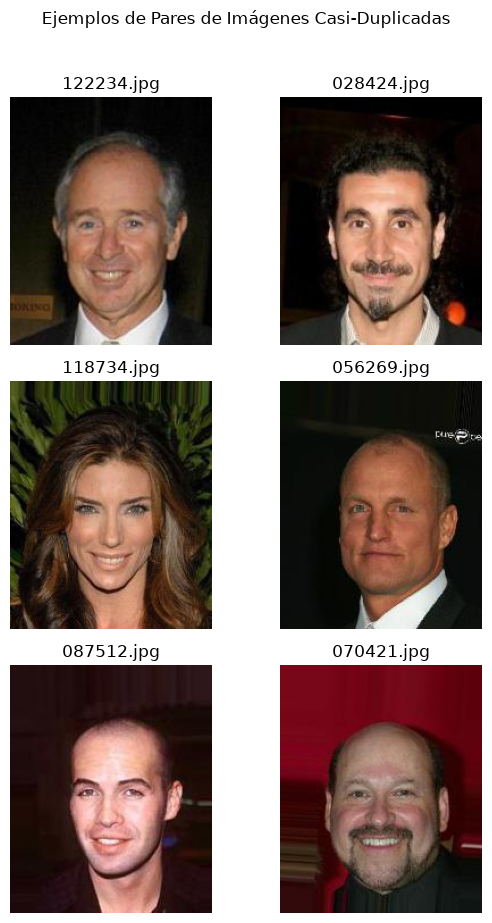


[CONCLUSIÓN] La detección de duplicados exactos y casi-duplicados es fundamental para evitar fugas de información (data leakage) entre los conjuntos de entrenamiento y prueba que se construirán en Machine Learning II.


In [16]:
# ==============================================================================
# Detección de Imágenes Duplicadas (Exactas y Casi-Duplicadas)
# ==============================================================================
import hashlib
from scipy.spatial.distance import pdist, squareform

def calcular_ahash(img_gray, hash_size=8):
    """
    Calcula un hash perceptual simple (Average Hash) para detectar imágenes
    visualmente similares (casi-duplicadas), no solo copias exactas de bytes.
    """
    reducida = cv2.resize(img_gray, (hash_size, hash_size), interpolation=cv2.INTER_AREA)
    promedio = reducida.mean()
    return (reducida > promedio).flatten()

print(f"[INFO] Buscando duplicados exactos y casi-duplicados en la muestra de {SAMPLE_SIZE} imágenes...")

hashes_md5 = []
hashes_perceptuales = []
ids_procesados = []

for img_name in sample_df.index:
    img_path = os.path.join(IMG_DIR, img_name)
    with open(img_path, 'rb') as f:
        contenido = f.read()
    hashes_md5.append(hashlib.md5(contenido).hexdigest())

    img_gray = cv2.imread(img_path, 0)
    if img_gray is not None:
        hashes_perceptuales.append(calcular_ahash(img_gray))
        ids_procesados.append(img_name)

# ------------------------------------------------------------------------
# 1. Duplicados EXACTOS (misma huella MD5, byte a byte)
# ------------------------------------------------------------------------
df_hashes = pd.DataFrame({'image_id': list(sample_df.index), 'md5': hashes_md5})
duplicados_exactos = df_hashes[df_hashes.duplicated(subset='md5', keep=False)]
num_duplicados_exactos = duplicados_exactos['md5'].nunique() if not duplicados_exactos.empty else 0

print(f"\n[EXACTOS] Grupos de imágenes idénticas (mismo archivo) encontrados: {num_duplicados_exactos}")
if num_duplicados_exactos > 0:
    display(duplicados_exactos.sort_values('md5').head(10))

# ------------------------------------------------------------------------
# 2. Imágenes CASI-DUPLICADAS (similitud perceptual, distancia de Hamming)
# ------------------------------------------------------------------------
matriz_hashes = np.array(hashes_perceptuales)
distancias = squareform(pdist(matriz_hashes, metric='hamming'))
np.fill_diagonal(distancias, 1)  # se descarta la comparación de cada imagen consigo misma

UMBRAL_SIMILITUD = 0.05  # equivalente a <= ~3 bits distintos de 64
indices_similares = np.argwhere(distancias <= UMBRAL_SIMILITUD)
pares_similares = {tuple(sorted((int(i), int(j)))) for i, j in indices_similares}

print(f"[CASI-DUPLICADOS] Pares de imágenes visualmente muy similares encontrados: {len(pares_similares)}")

if pares_similares:
    muestra_pares = list(pares_similares)[:3]
    fig, axes = plt.subplots(len(muestra_pares), 2, figsize=(6, 3 * len(muestra_pares)))
    if len(muestra_pares) == 1:
        axes = [axes]
    for fila, (i, j) in enumerate(muestra_pares):
        for col, idx in enumerate((i, j)):
            nombre = ids_procesados[idx]
            img = cv2.cvtColor(cv2.imread(os.path.join(IMG_DIR, nombre)), cv2.COLOR_BGR2RGB)
            axes[fila][col].imshow(img)
            axes[fila][col].set_title(nombre)
            axes[fila][col].axis('off')
    plt.suptitle("Ejemplos de Pares de Imágenes Casi-Duplicadas", y=1.02)
    plt.tight_layout()
    plt.show()

print("\n[CONCLUSIÓN] La detección de duplicados exactos y casi-duplicados es fundamental "
      "para evitar fugas de información (data leakage) entre los conjuntos de entrenamiento "
      "y prueba que se construirán en Machine Learning II.")


## Fase 4: Preparación de los Datos (Data Preparation)

En esta etapa de la metodología CRISP-DM, se transforma el conjunto de datos crudo en un subconjunto curado y estandarizado, preparándolo para la posterior extracción de descriptores matemáticos. De acuerdo con los lineamientos de la actividad, se aplican las siguientes técnicas de preprocesamiento:

1. **Muestreo de Producción:** Selección de 25,000 instancias aleatorias para garantizar la viabilidad computacional del entrenamiento.
2. **Filtrado de Anomalías (Limpieza):** Descarte automático de imágenes corruptas o con intensidad lumínica extrema, utilizando umbrales derivados del análisis exploratorio previo (Fase 3).
3. **Estandarización Espacial (Redimensionamiento):** Ajuste de las dimensiones de todas las matrices fotográficas a una resolución uniforme de 128x128 píxeles mediante interpolación de área.
4. **Conversión a Escala de Grises:** Se documenta explícitamente el efecto de convertir las imágenes RGB a un único canal de luminancia, transformación requerida por los descriptores estadísticos y de textura de la Fase de extracción de características.
5. **Normalización de Intensidades:** Se escala el rango de valores de píxel de [0, 255] a [0, 1], preservando una copia normalizada del dataset (`imagenes_normalizadas`) para su uso en algoritmos sensibles a la escala de las variables.
6. **Organización del Dataset:** Las imágenes curadas y sus metadatos se organizan en estructuras alineadas por índice (`image_id`) para su uso consistente en las siguientes fases.


In [17]:
# ==============================================================================
# 1. Configuración de Parámetros del Pipeline
# ==============================================================================
# Se establece el volumen de datos a procesar para el conjunto final.
TOTAL_PROCESAMIENTO = 25000

# Resolución estándar requerida para los algoritmos de extracción (HOG, LBP).
DIMENSION_ESTANDAR = (128, 128)

# Umbrales de intensidad basados en la evaluación de anomalías del EDA.
# Se descartan imágenes excesivamente oscuras (<40) o sobreexpuestas (>240).
UMBRAL_OSCURO = 40
UMBRAL_BRILLANTE = 240

# ==============================================================================
# 2. Selección y Filtrado de Datos
# ==============================================================================
print(f"[INFO] Iniciando Fase de Preparación con {TOTAL_PROCESAMIENTO} instancias base...")

# Extracción de la muestra de producción desde el DataFrame original.
df_produccion = df_attr.sample(n=TOTAL_PROCESAMIENTO, random_state=42).copy()

# Estructuras de datos para retener en memoria los activos procesados.
imagenes_limpias = []
rutas_validas = []

descartadas_por_anomalia = 0

# ==============================================================================
# 3. Procesamiento y Estandarización Espacial
# ==============================================================================
# Bucle de iteración sobre los identificadores (nombres de imagen).
for img_name in df_produccion.index:
    img_path = os.path.join(IMG_DIR, img_name)
    
    # Lectura inicial en escala de grises para evaluación de integridad e intensidad.
    img_gray = cv2.imread(img_path, 0)
    
    if img_gray is not None:
        brillo = np.mean(img_gray)
        
        # Aplicación del filtro lógico de intensidad (Purgado de Outliers).
        if UMBRAL_OSCURO <= brillo <= UMBRAL_BRILLANTE:
            # Si la matriz cumple los criterios, se lee en formato RGB (3 canales)
            # para preservar la versatilidad ante distintos algoritmos de extracción.
            img_color = cv2.imread(img_path)
            
            # Estandarización de la resolución mediante interpolación de área, 
            # técnica recomendada para la reducción de dimensiones fotográficas.
            img_resized = cv2.resize(img_color, DIMENSION_ESTANDAR, interpolation=cv2.INTER_AREA)
            
            # Inserción de la matriz estandarizada y su identificador.
            imagenes_limpias.append(img_resized)
            rutas_validas.append(img_name)
        else:
            descartadas_por_anomalia += 1
    else:
        # Descarte de archivos irrecuperables (NoneType).
        descartadas_por_anomalia += 1

# ==============================================================================
# 4. Consolidación del Dataset Curado
# ==============================================================================
# Construcción del DataFrame definitivo cruzando las rutas válidas con sus metadatos.
df_limpio = df_produccion.loc[rutas_validas].copy()

print("--- Resumen de Limpieza y Estandarización ---")
print(f"Instancias originales analizadas: {TOTAL_PROCESAMIENTO}")
print(f"Imágenes descartadas (Anomalías de iluminación/corrupción): {descartadas_por_anomalia}")
print(f"Instancias válidas finales (Dataset Curado): {len(df_limpio)}")
print(f"Resolución espacial uniforme aplicada: {DIMENSION_ESTANDAR}")
print("[INFO] Conjunto de datos optimizado. Listo para el motor de extracción (Fase 4).")

[INFO] Iniciando Fase de Preparación con 25000 instancias base...
--- Resumen de Limpieza y Estandarización ---
Instancias originales analizadas: 25000
Imágenes descartadas (Anomalías de iluminación/corrupción): 181
Instancias válidas finales (Dataset Curado): 24819
Resolución espacial uniforme aplicada: (128, 128)
[INFO] Conjunto de datos optimizado. Listo para el motor de extracción (Fase 4).


### Demostración de Conversión a Escala de Grises y Normalización de Intensidades

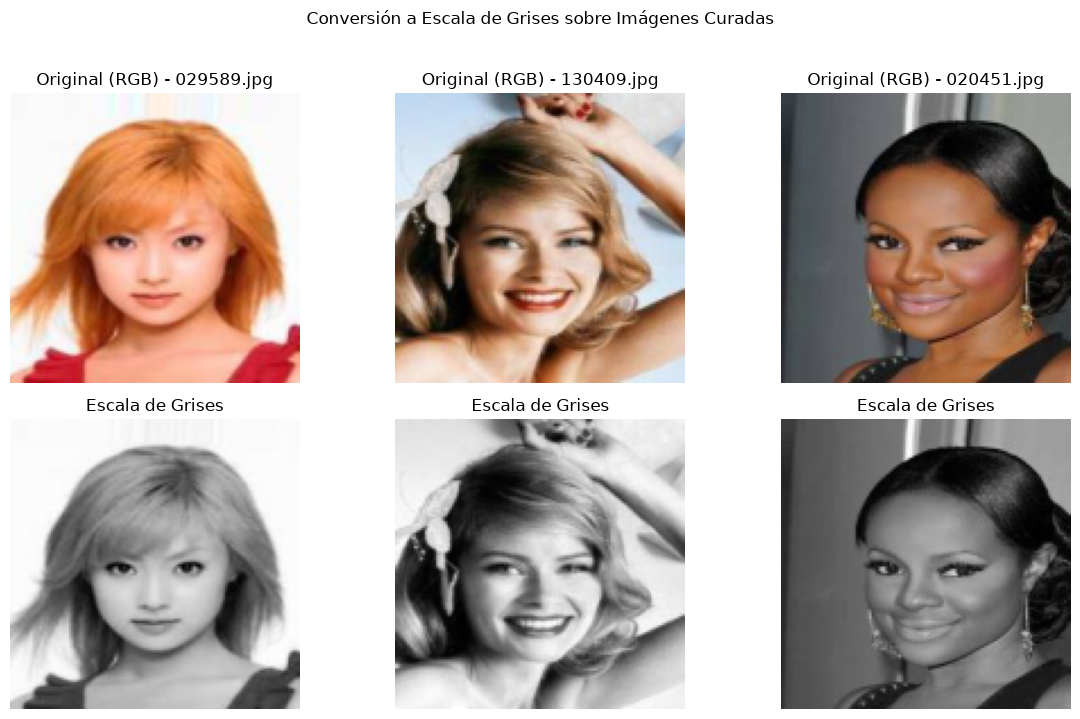

[INFO] Normalización completada sobre 24819 imágenes.
Rango original de intensidades: [0, 255]
Rango normalizado de intensidades: [0.00, 1.00]


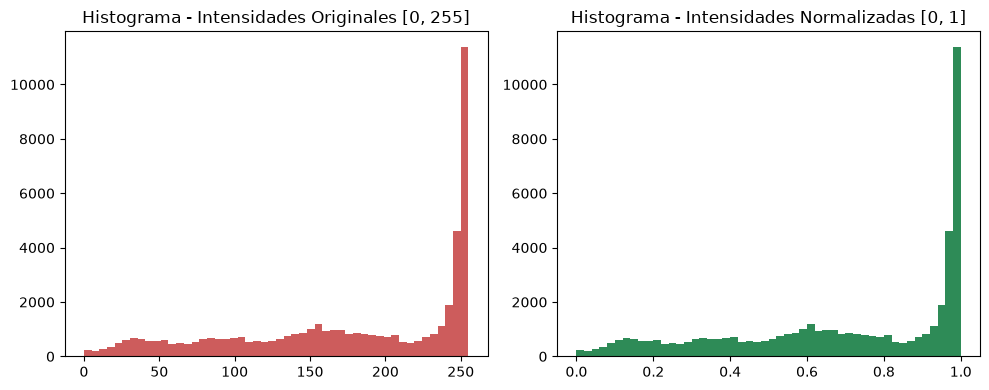

In [18]:
# ==============================================================================
# Conversión a Escala de Grises (demostración visual)
# ==============================================================================
# Aunque cada función extractora de características (Fase de Extracción) realiza
# internamente la conversión a escala de grises (paso indispensable para los
# descriptores estadísticos, LBP, GLCM y HOG), se documenta aquí explícitamente
# el efecto de esta transformación sobre una muestra de imágenes curadas.

indices_demo = np.random.RandomState(42).choice(len(imagenes_limpias), size=3, replace=False)

fig, axes = plt.subplots(2, 3, figsize=(12, 7))
for col, idx in enumerate(indices_demo):
    img_color = cv2.cvtColor(imagenes_limpias[idx], cv2.COLOR_BGR2RGB)
    img_gray = cv2.cvtColor(imagenes_limpias[idx], cv2.COLOR_BGR2GRAY)

    axes[0, col].imshow(img_color)
    axes[0, col].set_title(f"Original (RGB) - {rutas_validas[idx]}")
    axes[0, col].axis('off')

    axes[1, col].imshow(img_gray, cmap='gray')
    axes[1, col].set_title("Escala de Grises")
    axes[1, col].axis('off')

plt.suptitle("Conversión a Escala de Grises sobre Imágenes Curadas", y=1.02)
plt.tight_layout()
plt.show()

# ==============================================================================
# Normalización de Intensidades
# ==============================================================================
# Se escala el rango de valores de píxel de [0, 255] a [0, 1]. Esta versión
# normalizada se conserva en memoria (imagenes_normalizadas) para su eventual uso
# en algoritmos de Machine Learning II sensibles a la escala de las variables
# (redes neuronales, SVM, etc.). Los descriptores estadísticos de la siguiente
# fase se calculan sobre la escala original [0, 255] para mantener la
# interpretabilidad de las métricas (media, mediana, etc.) solicitadas en la
# actividad.

imagenes_normalizadas = [img.astype(np.float32) / 255.0 for img in imagenes_limpias]

print(f"[INFO] Normalización completada sobre {len(imagenes_normalizadas)} imágenes.")
print("Rango original de intensidades: [0, 255]")
print(f"Rango normalizado de intensidades: [{imagenes_normalizadas[0].min():.2f}, "
      f"{imagenes_normalizadas[0].max():.2f}]")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].hist(imagenes_limpias[indices_demo[0]].flatten(), bins=50, color='indianred')
axes[0].set_title("Histograma - Intensidades Originales [0, 255]")
axes[1].hist(imagenes_normalizadas[indices_demo[0]].flatten(), bins=50, color='seagreen')
axes[1].set_title("Histograma - Intensidades Normalizadas [0, 1]")
plt.tight_layout()
plt.show()


### Extracción de Características (parte de la Fase 4: Preparación de los Datos)

Una vez curadas, redimensionadas, convertidas a escala de grises y normalizadas, las imágenes se transforman en vectores de características numéricas. El objetivo es representar la información visual de manera matemática para el posterior modelado en Machine Learning II.

#### 4.1 Módulo de Descriptores Estadísticos
Se extraen medidas de tendencia central y dispersión de la distribución de intensidades (escala de grises) de la imagen: **media, mediana, varianza, desviación estándar, energía y entropía**, además de asimetría y curtosis como métricas complementarias. Estas métricas capturan la iluminación general, el contraste global y la complejidad de la textura de cada rostro.


In [19]:
# ==============================================================================
# 4.1 Definición de Funciones para Descriptores Estadísticos
# ==============================================================================
import numpy as np
import cv2
from scipy.stats import skew, kurtosis

def extraer_estadisticos(imagen_rgb):
    """
    Calcula descriptores estadísticos sobre el canal de luminancia de la imagen.
    """
    # CONCEPTO TÉCNICO: Escala de Grises (Luminancia).
    # ¿Por qué quitamos el color? Porque para reconocer la estructura de un rostro 
    # (la forma de la nariz, la profundidad de los ojos), el color de la piel o 
    # del maquillaje es irrelevante y añade "ruido" computacional. Al pasar a grises, 
    # nos quedamos solo con la intensidad de la luz (sombras y brillos), que es lo 
    # que realmente define la volumetría de una cara.
    img_gray = cv2.cvtColor(imagen_rgb, cv2.COLOR_BGR2GRAY)

    # ----------------------------------------------------------------------
    # Métricas de tendencia central y dispersión
    # ----------------------------------------------------------------------
    # Media: Es el promedio de todos los píxeles. Nos dice si la foto, en general, 
    # es muy oscura (valores cercanos a 0) o muy iluminada (cercanos a 255).
    media = np.mean(img_gray)
    
    # Mediana: Es el píxel que está exactamente en el medio si los ordenamos. 
    # A diferencia de la media, la mediana no se deja engañar si hay un reflejo 
    # de luz muy fuerte (un flash) en una parte pequeña de la cara.
    mediana = np.median(img_gray)
    
    # Varianza y Desviación Estándar (Std): Ambas miden el "Contraste".
    # Si la desviación estándar es alta, significa que hay píxeles muy negros y 
    # píxeles muy blancos (sombras fuertes). Si es baja, la imagen es "plana" 
    # o borrosa (los píxeles se parecen todos entre sí).
    var = np.var(img_gray)
    std = np.std(img_gray)

    # ----------------------------------------------------------------------
    # Teoría de la Información (Energía y Entropía)
    # ----------------------------------------------------------------------
    # Primero, calculamos un Histograma. Esto es simplemente contar: "¿Cuántos píxeles 
    # negros hay? ¿Cuántos grises? ¿Cuántos blancos?". Luego, dividimos esos conteos 
    # por el total de píxeles para obtener la "Probabilidad" de que un color aparezca.
    # El '+ 1e-10' es un truco matemático pequeñito para evitar que el programa 
    # colapse intentando dividir para cero.
    hist, _ = np.histogram(img_gray, bins=256, range=(0, 255))
    hist_prob = hist / (hist.sum() + 1e-10)

    # Energía: Mide la "Uniformidad". Matemáticamente es la suma de las probabilidades 
    # al cuadrado. Si una foto es casi toda del mismo color (ej. una pared de fondo), 
    # la energía es altísima. Si tiene muchos detalles, la energía es baja.
    energia = np.sum(hist_prob ** 2)

    # Entropía de Shannon: Es un concepto físico/informático que mide el "Caos" o 
    # la cantidad de información. Un rostro lleno de texturas (arrugas, cabello, 
    # poros, barba) es un sistema complejo, por lo que su Entropía será alta.
    entropia = -np.sum(hist_prob[hist_prob > 0] * np.log2(hist_prob[hist_prob > 0]))

    # ----------------------------------------------------------------------
    # Métricas de forma de la distribución (Asimetría y Curtosis)
    # ----------------------------------------------------------------------
    # Aplanamos la matriz 2D a una simple lista de números (1D) para analizarlos.
    pixeles_planos = img_gray.flatten()
    
    # Asimetría (Skewness): Nos dice hacia dónde se inclinan los tonos. Si es positiva, 
    # hay un exceso de tonos oscuros. Si es negativa, predominan los tonos claros.
    asimetria = skew(pixeles_planos)
    
    # Curtosis: Evalúa qué tan "puntiaguda" es la campana de Gauss de nuestros colores.
    # Si es muy alta, significa que casi todos los píxeles tienen el mismo tono exacto 
    # (muy común en fondos de estudio sólidos).
    curt = kurtosis(pixeles_planos)

    return [media, mediana, var, std, energia, entropia, asimetria, curt]

### 4.2 Módulo de Descriptores de Textura
Implementación de algoritmos avanzados para la captura de patrones locales y microestructuras faciales:
- **LBP (Local Binary Patterns):** Codifica las variaciones locales de intensidad (arrugas, bordes finos).
- **GLCM (Gray-Level Co-occurrence Matrix):** Extrae propiedades estadísticas espaciales (contraste, energía).
- **HOG (Histogram of Oriented Gradients):** Captura la orientación de los bordes, fundamental para la morfología facial.



In [20]:
# ==============================================================================
# 4.2 Definición de Funciones para Descriptores de Textura
# ==============================================================================
from skimage.feature import hog, local_binary_pattern, graycomatrix, graycoprops

def extraer_textura(imagen_rgb):
    """
    Aplica algoritmos avanzados (LBP, GLCM y HOG) para extraer patrones de textura.
    En reconocimiento facial, la textura es vital para distinguir detalles como 
    la rugosidad de la piel, la presencia de vello facial o la forma de las cejas.
    """
    img_gray = cv2.cvtColor(imagen_rgb, cv2.COLOR_BGR2GRAY)
    
    # ----------------------------------------------------------------------
    # 1. Extracción LBP (Local Binary Patterns - Patrones Binarios Locales)
    # ----------------------------------------------------------------------
    # ¿Qué hace LBP? Se para en un píxel y mira a sus 8 vecinos alrededor (radio=1). 
    # Si un vecino es más brillante, le pone un '1', si es más oscuro, un '0'. 
    # Esto forma un código binario. Es espectacular para detectar micro-texturas 
    # como poros, comisuras de los labios o marcas de acné, sin importar si 
    # la foto está muy oscura o muy clara (es invariante a la iluminación).
    radio = 1
    puntos = 8 * radio
    lbp = local_binary_pattern(img_gray, puntos, radio, method='uniform')
    
    # No guardamos la imagen LBP en sí, sino su "Histograma". Es decir, contamos 
    # con qué frecuencia aparecen los distintos tipos de patrones en la cara.
    (hist_lbp, _) = np.histogram(lbp.ravel(), bins=np.arange(0, puntos + 3), range=(0, puntos + 2))
    hist_lbp = hist_lbp.astype("float")
    hist_lbp /= (hist_lbp.sum() + 1e-6) # Lo normalizamos a porcentajes (0 a 1).
    
    # ----------------------------------------------------------------------
    # 2. Extracción GLCM (Gray-Level Co-occurrence Matrix)
    # ----------------------------------------------------------------------
    # ¿Qué hace GLCM? A diferencia del histograma normal que cuenta píxeles sueltos, 
    # GLCM analiza PARES de píxeles. Se pregunta: "¿Qué tan frecuente es que un 
    # píxel gris oscuro esté exactamente al lado derecho (ángulo 0, distancia 1) 
    # de un píxel gris claro?".
    glcm = graycomatrix(img_gray, distances=[1], angles=[0], levels=256, symmetric=True, normed=True)
    
    # De esa matriz gigante, extraemos 4 valores que resumen la textura de la piel:
    # Contraste: Intensidad de los cambios bruscos (ej. borde entre el pelo y la frente).
    contraste = graycoprops(glcm, 'contrast')[0, 0]
    # Correlación: Qué tan predecibles son los patrones lineales.
    correlacion = graycoprops(glcm, 'correlation')[0, 0]
    # Energía: Texturas repetitivas y constantes.
    energia = graycoprops(glcm, 'energy')[0, 0]
    # Homogeneidad: Suavidad de la imagen (ej. las mejillas suelen ser muy homogéneas).
    homogeneidad = graycoprops(glcm, 'homogeneity')[0, 0]
    
    # ----------------------------------------------------------------------
    # 3. Extracción HOG (Histogram of Oriented Gradients)
    # ----------------------------------------------------------------------
    # ¿Qué hace HOG? Es el algoritmo estrella para detección de formas. 
    # En lugar de ver los colores, calcula la "dirección de las sombras". 
    # Almacena hacia dónde apuntan los bordes (gradientes). En un rostro, HOG 
    # dibujaría esencialmente un mapa de flechas delineando la mandíbula, 
    # la nariz y la cuenca de los ojos.
    hog_features = hog(img_gray, orientations=8, pixels_per_cell=(16, 16),
                       cells_per_block=(2, 2), feature_vector=True)
    
    # CONCEPTO TÉCNICO VITAL: Evitando la "Maldición de la Dimensionalidad".
    # HOG nos devuelve un vector larguísimo (miles de características). Si metemos 
    # miles de columnas de golpe en nuestro archivo CSV, el modelo de Machine Learning 
    # podría sobreajustarse o tardar años en entrenar. 
    # Por eso, comprimimos toda esa información calculando solo la Media y la Desviación 
    # Estándar de esos gradientes. Así, resumimos la estructura global del rostro 
    # en solo 2 números eficientes.
    hog_media = np.mean(hog_features)
    hog_std = np.std(hog_features)
    
    return [contraste, correlacion, energia, homogeneidad, hog_media, hog_std] + list(hist_lbp)

#### 4.3 Módulo de Descriptores Geométricos y de Forma
Se detecta el rostro dentro de cada imagen mediante un clasificador en cascada de Haar (`haarcascade_frontalface_default`) para calcular directamente el **alto**, el **ancho** y la **relación ancho/alto** del rostro detectado, tal como lo solicita la actividad. Como descriptores geométricos complementarios se conservan los **Momentos de Hu** (invariantes a escala y rotación) y la **densidad de bordes estructurales** (Canny), útiles para capturar la forma global del rostro cuando no se detecta un rostro explícito (se usa entonces el tamaño completo de la imagen como respaldo).

In [21]:
# ==============================================================================
# 4.3 Definición de Funciones para Descriptores Geométricos
# ==============================================================================

# CONCEPTO TÉCNICO: Clasificador en Cascada de Haar (Viola-Jones).
# OpenCV incluye modelos pre-entrenados para detectar rostros (basados en contrastes 
# de luz claros y oscuros en zonas específicas como los ojos y la nariz). 
# Cargamos este clasificador con cv2.CascadeClassifier para que actúe como un 
# "escáner" que localiza la cara dentro de cada fotografía.
FACE_CASCADE = cv2.CascadeClassifier('haarcascade_frontalface_default.xml')

def extraer_geometricos(imagen_rgb):
    """
    Calcula el alto, ancho y relación del rostro detectado, junto con los 
    Momentos de Hu y la densidad de bordes como descriptores de forma complementarios.
    """
    # Convertimos a escala de grises porque el algoritmo de Haar no necesita color, 
    # solo los contrastes de iluminación para ubicar las facciones.
    img_gray = cv2.cvtColor(imagen_rgb, cv2.COLOR_BGR2GRAY)

    # ----------------------------------------------------------------------
    # 1. Detección del rostro y medición geométrica base
    # ----------------------------------------------------------------------
    # detectMultiScale escanea la imagen buscando patrones de rostros.
    # - scaleFactor=1.1: Reduce la imagen un 10% en cada paso para buscar caras de 
    #   diferentes tamaños (cerca o lejos).
    # - minNeighbors=5: Exige que haya al menos 5 "coincidencias vecinas" superpuestas 
    #   para confirmar que es una cara real, evitando falsos positivos.
    faces = FACE_CASCADE.detectMultiScale(img_gray, scaleFactor=1.1, minNeighbors=5,
                                           minSize=(30, 30))
    
    if len(faces) > 0:
        # ¿Qué pasa si la foto muestra a varias personas o fondos confusos? 
        # Usamos max() con una función lambda para filtrar todas las cajas detectadas 
        # y quedarnos estrictamente con la de mayor área (Ancho * Alto), que es el rostro principal.
        x, y, w, h = max(faces, key=lambda f: f[2] * f[3])
        alto_rostro, ancho_rostro = float(h), float(w)
    else:
        # PLAN DE RESPALDO (Fallback Logic): 
        # ¿Qué sucede si el modelo de Haar falla porque la persona está de perfil o 
        # hay muy poca luz? Si devolviéramos un error, perderíamos toda la foto. 
        # En su lugar, usamos un respaldo: asignamos las dimensiones totales de la 
        # imagen estandarizada (128x128) para no romper el flujo de datos del CSV.
        alto_rostro, ancho_rostro = float(img_gray.shape[0]), float(img_gray.shape[1])

    # Relación de Aspecto (Aspect Ratio): Es la división entre el ancho y el alto. 
    # Ayuda a diferenciar rostros alargados (ovalados) de rostros más anchos (redondos).
    relacion_ancho_alto = ancho_rostro / alto_rostro if alto_rostro > 0 else 0.0

    # ----------------------------------------------------------------------
    # 2. Momentos de Hu (Invarianza Geométrica)
    # ----------------------------------------------------------------------
    # Los Momentos de Hu son 7 propiedades matemáticas calculadas sobre la silueta 
    # de la imagen. Su superpoder es que son "invariantes": no cambian aunque el 
    # objeto rote, se escale o se refleje.
    momentos = cv2.moments(img_gray)
    hu_moments = cv2.HuMoments(momentos).flatten()
    
    # CONCEPTO TÉCNICO: Transformación Logarítmica.
    # Los valores de los Momentos de Hu crudos varían de manera salvaje (algunos son 
    # números gigantes y otros microscópicos cercanos a cero). Para evitar problemas 
    # numéricos de desbordamiento en Machine Learning, les aplicamos una escala logarítmica 
    # con un pequeño factor de seguridad (+ 1e-10). np.errstate silencia advertencias 
    # si el sistema intenta calcular el logaritmo de cero.
    with np.errstate(divide='ignore', invalid='ignore'):
        hu_log = -np.sign(hu_moments) * np.log10(np.abs(hu_moments) + 1e-10)

    # ----------------------------------------------------------------------
    # 3. Densidad de Bordes Estructurales (Algoritmo de Canny)
    # ----------------------------------------------------------------------
    # El filtro de Canny es el estándar de oro en visión artificial para detectar bordes 
    # filosos (con umbrales de intensidad 100 y 200). 
    # Para convertirlo en un número útil, sumamos cuántos píxeles forman parte de un 
    # borde (bordes > 0) y lo dividimos por el área total de la imagen. Esto nos da 
    # la "Densidad de Bordes": una medida de qué tan detallado o recargado de líneas es el rostro.
    bordes = cv2.Canny(img_gray, threshold1=100, threshold2=200)
    densidad_bordes = np.sum(bordes > 0) / (bordes.shape[0] * bordes.shape[1])

    return [alto_rostro, ancho_rostro, relacion_ancho_alto] + list(hu_log) + [densidad_bordes]

#### 4.4 Integración y Ejecución del Pipeline (Motor Principal)
Invocación sistemática de los módulos extractores sobre el conjunto de datos curado, ensamblando la Matriz de Características (Feature Matrix) final.

In [22]:
# ==============================================================================
# 4.4 Motor Iterativo de Extracción y Consolidación de la Matriz de Diseño
# ==============================================================================
import pandas as pd
from tqdm import tqdm # Librería profesional que dibuja una barra de carga en tiempo real

print(f"[INFO] Inicializando Motor de Extracción sobre {len(imagenes_limpias)} instancias...")

vectores_caracteristicas = []

# Bucle principal impulsado por 'tqdm'. Como procesar miles de imágenes toma varios 
# minutos, la barra de progreso nos muestra el porcentaje exacto completado, el 
# tiempo transcurrido y la velocidad estimada por segundo.
for img in tqdm(imagenes_limpias, desc="Extrayendo Descriptores"):
    
    # CONCEPTO TÉCNICO: Arquitectura Modular (Pipeline).
    # En lugar de mezclar todo en un código gigante, invocamos independientemente 
    # nuestras tres funciones especializadas: Estadísticas, Texturas y Geometría.
    vec_est = extraer_estadisticos(img)
    vec_tex = extraer_textura(img)
    vec_geo = extraer_geometricos(img)
    
    # CONCEPTO TÉCNICO: Concatenación Espacial.
    # En Python, sumar dos listas (ej: [1,2] + [3,4] = [1,2,3,4]) las une una detrás 
    # de otra. Unimos los 3 vectores en una sola gran tira numérica que representa 
    # TODA la radiografía matemática de esa imagen en particular.
    vector_instancia = vec_est + vec_tex + vec_geo
    vectores_caracteristicas.append(vector_instancia)

# ----------------------------------------------------------------------
# Construcción dinámica de los nombres de columnas
# ----------------------------------------------------------------------
# Para que nuestro archivo CSV sea profesional, cada columna numérica debe tener 
# un nombre claro que indique a qué categoría pertenece (Estadística, Textura o Geometría).
cols_est = ['Stat_Media', 'Stat_Mediana', 'Stat_Var', 'Stat_Std', 'Stat_Energia',
            'Stat_Entropia', 'Stat_Skew', 'Stat_Kurtosis']
cols_tex = ['Tex_GLCM_Contraste', 'Tex_GLCM_Correlacion', 'Tex_GLCM_Energia', 
            'Tex_GLCM_Homogeneidad', 'Tex_HOG_Media', 'Tex_HOG_Std'] + \
           [f'Tex_LBP_{i}' for i in range(10)]
cols_geo = ['Geo_Alto_Rostro', 'Geo_Ancho_Rostro', 'Geo_Relacion_Ancho_Alto'] + \
           [f'Geo_Hu_{i}' for i in range(7)] + ['Geo_Densidad_Bordes']

nombres_columnas = cols_est + cols_tex + cols_geo

# Transformamos la lista gigante de listas en un DataFrame definitivo de Pandas 
# (nuestra matriz de características X).
df_features = pd.DataFrame(vectores_caracteristicas, columns=nombres_columnas)

# Restauramos los nombres originales de las fotos (ej. "00001.jpg") como el índice 
# de la tabla, asegurando que cada vector matemático quede perfectamente vinculado a su foto real.
df_features.index = rutas_validas 

print(f"\n[INFO] Fase de Extracción Completada. Matriz de características generada con éxito.")
print(f"[INFO] Dimensiones finales del conjunto de datos (Instancias, Atributos): {df_features.shape}")

# ==============================================================================
# Verificación de Calidad de la Matriz de Características
# ==============================================================================
# Antes de exportar, hacemos una auditoría interna para buscar errores matemáticos.
# - isnull(): Busca valores nulos (vacíos).
# - isinf(): Busca valores infinitos (provocados por divisiones accidentales por cero).
n_nulos = df_features.isnull().sum().sum()
n_infinitos = np.isinf(df_features.select_dtypes(include=[np.number])).sum().sum()

print(f"[INFO] Valores nulos detectados en la matriz de características: {n_nulos}")
print(f"[INFO] Valores infinitos detectados en la matriz de características: {n_infinitos}")

if n_nulos > 0 or n_infinitos > 0:
    # FILOSOFÍA DE LIMPIEZA PROFESIONAL: 
    # Si encontráramos algún error, en lugar de borrar toda la fila de la persona 
    # (lo que destruiría valiosa información de entrenamiento), reemplazamos los 
    # infinitos por NaN y aplicamos "Imputación por Mediana". Es decir, rellenamos 
    # el espacio vacío con el valor promedio/mediano de esa misma columna en todo el dataset.
    df_features = df_features.replace([np.inf, -np.inf], np.nan)
    df_features = df_features.fillna(df_features.median(numeric_only=True))
    print("[INFO] Valores nulos/infinitos corregidos mediante imputación por mediana.")
else:
    print("[INFO] La matriz de características no presenta valores nulos ni infinitos.")

# Previsualización estructurada del resultado final
display(df_features.head(3))

[INFO] Inicializando Motor de Extracción sobre 24819 instancias...


Extrayendo Descriptores: 100%|██████████| 24819/24819 [12:19<00:00, 33.57it/s]



[INFO] Fase de Extracción Completada. Matriz de características generada con éxito.
[INFO] Dimensiones finales del conjunto de datos (Instancias, Atributos): (24819, 35)
[INFO] Valores nulos detectados en la matriz de características: 0
[INFO] Valores infinitos detectados en la matriz de características: 0
[INFO] La matriz de características no presenta valores nulos ni infinitos.


,Stat_Media,Stat_Mediana,Stat_Var,Stat_Std,Stat_Energia,Stat_Entropia,Stat_Skew,Stat_Kurtosis,Tex_GLCM_Contraste,Tex_GLCM_Correlacion,...,Geo_Ancho_Rostro,Geo_Relacion_Ancho_Alto,Geo_Hu_0,Geo_Hu_1,Geo_Hu_2,Geo_Hu_3,Geo_Hu_4,Geo_Hu_5,Geo_Hu_6,Geo_Densidad_Bordes
093242.jpg,78.631042,76.0,1975.744180,44.449344,0.008735,7.182117,0.844063,0.844162,103.797306,0.973811,...,64.0,1.0,2.745674,7.583749,9.825103,9.989913,-10.0,-9.999999,10.0,0.060730
121414.jpg,139.525940,137.0,6466.726256,80.415958,0.017215,7.338813,-0.002726,-1.444026,296.805364,0.977012,...,69.0,1.0,2.944746,7.790652,9.800636,9.932916,-10.0,9.999991,10.0,0.117126
010625.jpg,150.341309,162.0,6718.920496,81.969022,0.005938,7.708304,-0.334655,-1.317712,166.620571,0.987577,...,62.0,1.0,2.976135,7.530968,9.955634,9.955679,10.0,-9.999992,-10.0,0.095520


## Fase 5: Construcción del Dataset (Consolidación, Escalado, PCA y Exportación)

En esta fase final se integran las características extraídas con las etiquetas originales, se verifica la calidad del dataset resultante, se reduce su dimensionalidad mediante PCA y se exporta el archivo CSV que servirá como insumo para Machine Learning II.

In [23]:
# ==============================================================================
# 5.1 Fusión de Atributos y Etiquetas
# ==============================================================================
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import os

print("[INFO] Iniciando Consolidación y Reducción de Dimensionalidad (Fase 5)...")

# 1. Unimos las características extraídas (X) con los 40 atributos originales (y)
# Usamos el índice (el nombre de la imagen) para asegurar que crucen perfectamente.
df_completo = df_features.join(df_limpio)

# ==============================================================================
# Verificación de Calidad del Dataset Consolidado
# ==============================================================================
# Se revisan valores faltantes, filas duplicadas y la estructura general de las
# variables antes de continuar con el escalado y la reducción de dimensionalidad,
# tal como lo exige la actividad para la Construcción del Dataset.
print("--- Verificación de Calidad del Dataset Consolidado ---")
print(f"Dimensiones (filas, columnas): {df_completo.shape}")
print(f"Valores faltantes totales: {df_completo.isnull().sum().sum()}")
print(f"Filas completamente duplicadas: {df_completo.duplicated().sum()}")
print("\nTipos de datos por columna (resumen):")
print(df_completo.dtypes.value_counts())

if df_completo.isnull().sum().sum() > 0:
    df_completo = df_completo.fillna(df_completo.median(numeric_only=True))
    print("[INFO] Valores faltantes imputados con la mediana de cada columna.")

# Número de características extraídas (dinámico, en lugar de un valor fijo hardcodeado)
n_features = df_features.shape[1]

# Separamos las variables independientes (X) de las dependientes/etiquetas (y)
X = df_completo.iloc[:, :n_features]
y = df_completo.iloc[:, n_features:]
print(f"\n[INFO] Variables independientes (X): {X.shape[1]} características extraídas.")
print(f"[INFO] Variables dependientes (y): {y.shape[1]} atributos originales de CelebA.")

# ==============================================================================
# 5.2 Estandarización Z-Score
# ==============================================================================
# Instanciamos y aplicamos el escalador para que todas las variables tengan media 0 y varianza 1
scaler = StandardScaler()
X_escalado = scaler.fit_transform(X)

# Convertimos de nuevo a DataFrame para mantener la estructura
X_escalado_df = pd.DataFrame(X_escalado, columns=X.columns, index=X.index)

# ==============================================================================
# 5.3 Reducción de Dimensionalidad (PCA)
# ==============================================================================
# Aplicamos PCA conservando el 95% de la varianza explicada
pca = PCA(n_components=0.95, random_state=42)
X_pca = pca.fit_transform(X_escalado_df)

# Creamos nombres para las nuevas columnas (Componentes Principales)
n_componentes = X_pca.shape[1]
columnas_pca = [f'PC_{i+1}' for i in range(n_componentes)]

# Convertimos el resultado de PCA a DataFrame
df_pca = pd.DataFrame(X_pca, columns=columnas_pca, index=X.index)

print(f"[INFO] PCA completado. Se redujo de {n_features} descriptores a {n_componentes} componentes principales.")
print(f"[INFO] Varianza total explicada: {sum(pca.explained_variance_ratio_) * 100:.2f}%")

# ==============================================================================
# 5.4 Exportación del Dataset Final Preparado
# ==============================================================================
# Unimos los componentes principales con las etiquetas originales
dataset_final = df_pca.join(y)

WORK_DIR = 'dataset'

# Definimos la ruta de salida
RUTA_SALIDA = os.path.join(WORK_DIR, 'dataset_celeba_preparado.csv')

# Exportamos a CSV
dataset_final.to_csv(RUTA_SALIDA)

print(f"[EXITO] Fase 5 concluida. Dataset exportado exitosamente a: {RUTA_SALIDA}")
print(f"[INFO] Dimensiones del archivo final: {dataset_final.shape}")

# ==============================================================================
# Verificación Final del Dataset Exportado (lectura de regreso desde disco)
# ==============================================================================
df_verificacion = pd.read_csv(RUTA_SALIDA, index_col=0)

print("\n--- Verificación del Archivo CSV Exportado ---")
print(f"Filas x Columnas: {df_verificacion.shape}")
print(f"Valores faltantes en el archivo exportado: {df_verificacion.isnull().sum().sum()}")
print(f"Filas duplicadas en el archivo exportado: {df_verificacion.duplicated().sum()}")
print("\nEstructura de variables (dtypes):")
print(df_verificacion.dtypes.value_counts())
display(df_verificacion.head(3))

[INFO] Iniciando Consolidación y Reducción de Dimensionalidad (Fase 5)...
--- Verificación de Calidad del Dataset Consolidado ---
Dimensiones (filas, columnas): (24819, 76)
Valores faltantes totales: 0
Filas completamente duplicadas: 2

Tipos de datos por columna (resumen):
int64      40
float64    35
str         1
Name: count, dtype: int64

[INFO] Variables independientes (X): 35 características extraídas.
[INFO] Variables dependientes (y): 41 atributos originales de CelebA.
[INFO] PCA completado. Se redujo de 35 descriptores a 16 componentes principales.
[INFO] Varianza total explicada: 95.15%
[EXITO] Fase 5 concluida. Dataset exportado exitosamente a: dataset\dataset_celeba_preparado.csv
[INFO] Dimensiones del archivo final: (24819, 57)

--- Verificación del Archivo CSV Exportado ---
Filas x Columnas: (24819, 57)
Valores faltantes en el archivo exportado: 0
Filas duplicadas en el archivo exportado: 2

Estructura de variables (dtypes):
int64      40
float64    16
str         1
Name: 

,PC_1,PC_2,PC_3,PC_4,PC_5,PC_6,PC_7,PC_8,PC_9,PC_10,...,Smiling,Straight_Hair,Wavy_Hair,Wearing_Earrings,Wearing_Hat,Wearing_Lipstick,Wearing_Necklace,Wearing_Necktie,Young,Gender_Label
093242.jpg,-3.124098,-1.456258,-0.683192,-2.055676,-0.938524,-1.298313,0.465575,-1.713788,0.667023,-0.522216,...,-1,-1,1,-1,-1,-1,-1,-1,1,Hombre
121414.jpg,2.276714,2.104958,-0.722690,2.125378,-0.224841,0.628891,-1.390041,-0.406733,0.989141,1.234447,...,-1,-1,-1,-1,-1,1,-1,-1,1,Mujer
010625.jpg,-0.464847,2.615519,-0.292895,1.576694,-0.399452,-2.807625,-0.378359,0.635806,-0.946231,-0.894700,...,-1,-1,1,-1,-1,-1,-1,-1,1,Hombre


## Fase 6: Interpretación de Resultados

Se analizan las características obtenidas para determinar cuáles aportan más información a la representación de los rostros humanos, apoyándose en las cargas (*loadings*) del Análisis de Componentes Principales (PCA) calculado en la Fase 5.

--- Top 8 características originales con mayor peso en el Primer Componente Principal (PC_1) ---


Tex_GLCM_Homogeneidad    0.292
Tex_HOG_Media            0.288
Tex_LBP_8                0.285
Tex_LBP_2                0.282
Tex_HOG_Std              0.280
Tex_GLCM_Energia         0.266
Tex_LBP_1                0.253
Stat_Entropia            0.236
Name: PC_1, dtype: float64


--- Top 8 características originales con mayor peso en el Segundo Componente Principal (PC_2) ---


Stat_Media            0.376
Stat_Mediana          0.368
Geo_Hu_0              0.358
Stat_Skew             0.344
Geo_Hu_3              0.293
Geo_Hu_2              0.272
Geo_Hu_1              0.252
Tex_GLCM_Contraste    0.210
Name: PC_2, dtype: float64

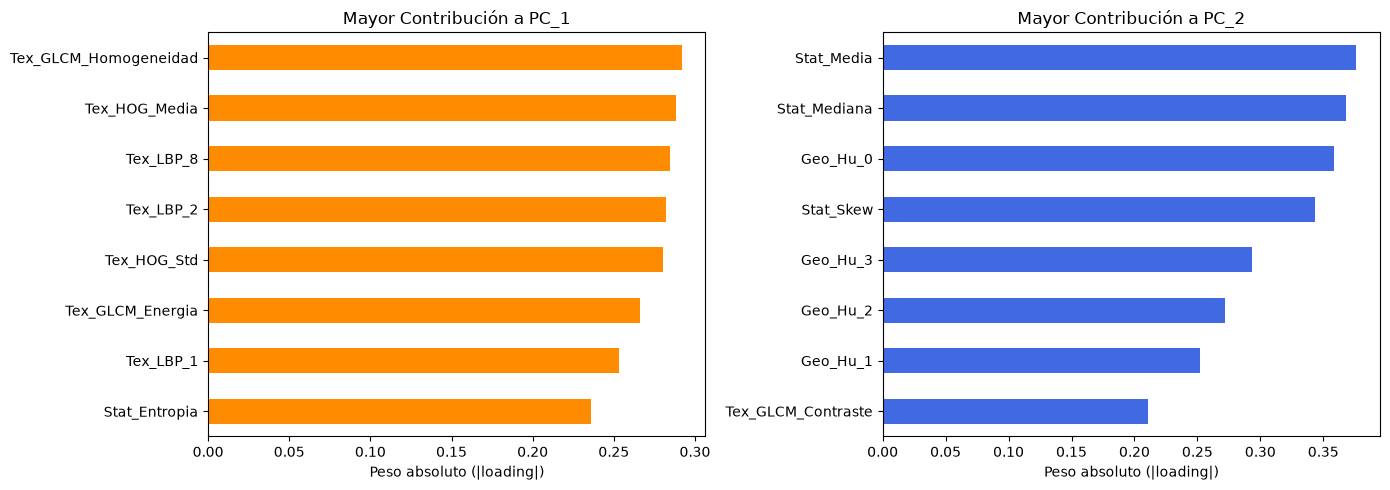

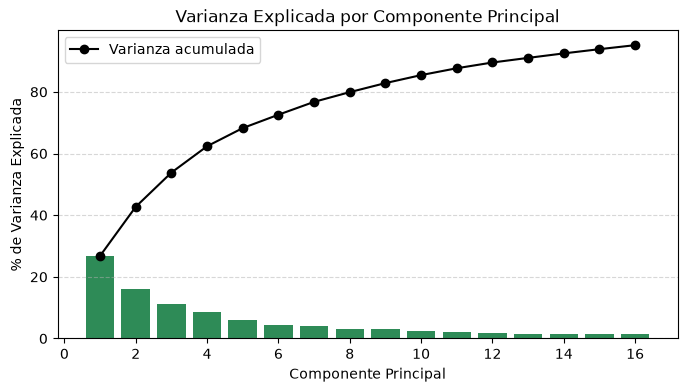

In [24]:
# ==============================================================================
# Fase 6.1: Análisis de Importancia de las Características Originales en el PCA
# ==============================================================================
loadings = pd.DataFrame(
    pca.components_.T,
    index=X.columns,
    columns=[f'PC_{i+1}' for i in range(n_componentes)]
)

print("--- Top 8 características originales con mayor peso en el Primer Componente Principal (PC_1) ---")
top_pc1 = loadings['PC_1'].abs().sort_values(ascending=False).head(8)
display(top_pc1.round(3))

if n_componentes > 1:
    print("\n--- Top 8 características originales con mayor peso en el Segundo Componente Principal (PC_2) ---")
    top_pc2 = loadings['PC_2'].abs().sort_values(ascending=False).head(8)
    display(top_pc2.round(3))

fig, axes = plt.subplots(1, 2 if n_componentes > 1 else 1, figsize=(14, 5))
axes = np.atleast_1d(axes)
top_pc1.sort_values().plot(kind='barh', ax=axes[0], color='darkorange')
axes[0].set_title("Mayor Contribución a PC_1")
axes[0].set_xlabel("Peso absoluto (|loading|)")

if n_componentes > 1:
    top_pc2.sort_values().plot(kind='barh', ax=axes[1], color='royalblue')
    axes[1].set_title("Mayor Contribución a PC_2")
    axes[1].set_xlabel("Peso absoluto (|loading|)")

plt.tight_layout()
plt.show()

# ==============================================================================
# Fase 6.2: Varianza Explicada por Componente
# ==============================================================================
plt.figure(figsize=(8, 4))
plt.bar(range(1, n_componentes + 1), pca.explained_variance_ratio_ * 100, color='seagreen')
plt.plot(range(1, n_componentes + 1), np.cumsum(pca.explained_variance_ratio_) * 100,
         color='black', marker='o', label='Varianza acumulada')
plt.xlabel("Componente Principal")
plt.ylabel("% de Varianza Explicada")
plt.title("Varianza Explicada por Componente Principal")
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()


In [25]:
# ==============================================================================
# Resumen Automático de Hallazgos Clave del Proceso CRISP-DM
# ==============================================================================
print("=" * 70)
print("RESUMEN EJECUTIVO DEL PROCESO (Fases 1 a 5 de CRISP-DM)")
print("=" * 70)
print("1. Comprensión del Negocio: Se definieron 5 preguntas de investigación "
      "orientadas al balance, calidad y representación del dataset facial.")
print(f"2. Comprensión de los Datos: {num_images:,} imágenes analizadas, "
      f"{num_attributes} atributos disponibles, dataset de {tamano_gb:.2f} GB en disco.")
print(f"3. EDA: Se detectaron {num_outliers} imágenes con intensidad anómala "
      f"(muestra de {SAMPLE_SIZE}), {num_duplicados_exactos} grupos de duplicados exactos "
      f"y {len(pares_similares)} pares de imágenes casi-duplicadas en la muestra analizada.")
print(f"4. Preparación de los Datos: De {TOTAL_PROCESAMIENTO:,} instancias muestreadas, "
      f"{len(df_limpio):,} superaron los filtros de calidad ({descartadas_por_anomalia:,} descartadas), "
      f"y fueron estandarizadas a {DIMENSION_ESTANDAR}.")
print(f"5. Construcción del Dataset: Se extrajeron {df_features.shape[1]} características "
      f"(estadísticas, de textura y geométricas) por imagen, reducidas mediante PCA a "
      f"{n_componentes} componentes principales que explican el "
      f"{sum(pca.explained_variance_ratio_) * 100:.2f}% de la varianza total. "
      f"Dataset final exportado: {dataset_final.shape[0]:,} filas x {dataset_final.shape[1]} columnas.")
print("=" * 70)


RESUMEN EJECUTIVO DEL PROCESO (Fases 1 a 5 de CRISP-DM)
1. Comprensión del Negocio: Se definieron 5 preguntas de investigación orientadas al balance, calidad y representación del dataset facial.
2. Comprensión de los Datos: 202,599 imágenes analizadas, 40 atributos disponibles, dataset de 1.31 GB en disco.
3. EDA: Se detectaron 40 imágenes con intensidad anómala (muestra de 2000), 0 grupos de duplicados exactos y 300 pares de imágenes casi-duplicadas en la muestra analizada.
4. Preparación de los Datos: De 25,000 instancias muestreadas, 24,819 superaron los filtros de calidad (181 descartadas), y fueron estandarizadas a (128, 128).
5. Construcción del Dataset: Se extrajeron 35 características (estadísticas, de textura y geométricas) por imagen, reducidas mediante PCA a 16 componentes principales que explican el 95.15% de la varianza total. Dataset final exportado: 24,819 filas x 57 columnas.


## Conclusiones y Recomendaciones

### Principales Hallazgos
- **Balance de clases:** El análisis evidenció que, si bien la variable de género se encuentra razonablemente balanceada, existen atributos categóricos (p. ej. uso de gafas, presencia de barba) con un fuerte desbalance hacia la clase negativa, lo cual deberá tratarse en Machine Learning II mediante técnicas de sobremuestreo/submuestreo o ponderación de clases.
- **Calidad de las imágenes:** Se identificó un porcentaje de imágenes con intensidad lumínica extrema (muy oscuras o sobreexpuestas) y un subconjunto adicional con bajo contraste, ambos indicadores de posible baja calidad visual. Estas imágenes fueron descartadas en la Fase de Preparación de los Datos.
- **Duplicados:** La detección combinada de huellas MD5 (duplicados exactos) y hashing perceptual (casi-duplicados) confirma que es indispensable validar este aspecto antes de dividir los datos en conjuntos de entrenamiento/prueba, para evitar fuga de información (*data leakage*).
- **Características más informativas:** El análisis de las cargas (*loadings*) del PCA muestra qué descriptores (estadísticos, de textura o geométricos) concentran la mayor parte de la varianza explicada en los primeros componentes, lo que orienta sobre qué familia de características resulta más discriminante para este conjunto de datos.

### Importancia de la Preparación de Datos
El proceso confirma que un modelo de reconocimiento facial es tan bueno como la calidad de los datos que lo alimentan: imágenes duplicadas, corruptas, mal iluminadas o clases desbalanceadas pueden traducirse directamente en modelos sesgados o con pobre capacidad de generalización. La reducción de dimensionalidad mediante PCA, además, permite mitigar la maldición de la dimensionalidad sin sacrificar de forma significativa la información discriminante del conjunto de datos.

### Recomendaciones para Machine Learning II
1. Utilizar el archivo `dataset_celeba_preparado.csv` como insumo directo para el entrenamiento de modelos de clasificación.
2. Aplicar técnicas de balanceo de clases (SMOTE, `class_weight`) para los atributos con mayor desbalance.
3. Evaluar el uso de arquitecturas de Deep Learning (CNNs) directamente sobre las imágenes normalizadas (`imagenes_normalizadas`) como alternativa complementaria a los descriptores manuales extraídos en este notebook.
4. Repetir el pipeline de limpieza (Fase 4) incrementando `TOTAL_PROCESAMIENTO` si se dispone de mayor capacidad computacional, para mejorar la representatividad del dataset final.

### Referencias Bibliográficas (APA 7)
Liu, Z., Luo, P., Wang, X., & Tang, X. (2015). *Deep learning face attributes in the wild*. Proceedings of the IEEE International Conference on Computer Vision (ICCV), 3730-3738. https://doi.org/10.1109/ICCV.2015.425

Li, J. (2018). *CelebFaces Attributes (CelebA) Dataset* [Data set]. Kaggle. https://www.kaggle.com/datasets/jessicali9530/celeba-dataset

Ojala, T., Pietikäinen, M., & Mäenpää, T. (2002). Multiresolution gray-scale and rotation invariant texture classification with local binary patterns. *IEEE Transactions on Pattern Analysis and Machine Intelligence, 24*(7), 971-987. https://doi.org/10.1109/TPAMI.2002.1017623

Dalal, N., & Triggs, B. (2005). Histograms of oriented gradients for human detection. *2005 IEEE Computer Society Conference on Computer Vision and Pattern Recognition (CVPR'05), 1*, 886-893. https://doi.org/10.1109/CVPR.2005.177
